In [1]:
library(vroom)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Boxplot Function

In [2]:
qtl.boxplot <- function(feature, snp, genotypes, count.mats, colors, unit='CPM', ylims=NULL) {
    snp.geno <- filter(genotypes, ID==snp) %>% select(-ID)
    snp.geno <- snp.geno[1,]
    snp.info <- rownames(snp.geno)
    
    ref <- str_split(snp.info, ":", simplify=T)[3]
    alt <- str_split(snp.info, ":", simplify=T)[4]
    rownames(snp.geno) <- 'Genotypes'
    
    feat.counts <- data.frame()
    for (cell in names(count.mats)) {
        feat.counts <- rbind(feat.counts,count.mats[[cell]][feature,colnames(snp.geno)])
    }
    rownames(feat.counts) <- names(count.mats)
    
    plot.data <- data.frame(t(rbind(feat.counts, snp.geno)))
    #colnames(plot.data) <- c('Feature','Genotype')
    
    plot.data$geno <- paste0(ref,ref)
    plot.data$geno[plot.data$Genotype == 1] <- paste0(ref,alt)
    plot.data$geno[plot.data$Genotype == 2] <- paste0(alt,alt)
    plot.data <- tidyr::pivot_longer(plot.data, cols = all_of(names(TPM)), values_to = 'Feature', names_to = 'cell')
    
    p1 <- ggplot(plot.data, aes(x=interaction(geno, cell), y=Feature, fill=cell)) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_jitter(width=.2, alpha=.5) +
        labs(y=paste0(feature, " (", unit, ')'), x='Genotype') +
        theme_classic(base_size=20) +
        scale_fill_manual(values=colors) + 
        scale_x_discrete(labels = function(x) gsub("\\..*", "", x))
                         
    if(!is.null(ylims)) {
        p1 <- p1 + ylim(ylims)
    }
    print(p1)
}

In [3]:
qtl.boxplot.flip <- function(feature, snp, genotypes, count.mats, colors, unit='CPM', ylims=NULL) {
    snp.geno <- filter(genotypes, ID==snp) %>% select(-ID)
    snp.geno <- snp.geno[1,]
    snp.info <- rownames(snp.geno)
    
    ref <- str_split(snp.info, ":", simplify=T)[3]
    alt <- str_split(snp.info, ":", simplify=T)[4]
    rownames(snp.geno) <- 'Genotypes'
    
    feat.counts <- data.frame()
    for (cell in names(count.mats)) {
        feat.counts <- rbind(feat.counts,count.mats[[cell]][feature,colnames(snp.geno)])
    }
    rownames(feat.counts) <- names(count.mats)
    
    plot.data <- data.frame(t(rbind(feat.counts, snp.geno)))
    #colnames(plot.data) <- c('Feature','Genotype')
    
    plot.data$geno <- paste0(ref,ref)
    plot.data$geno[plot.data$Genotype == 1] <- paste0(ref,alt)
    plot.data$geno[plot.data$Genotype == 2] <- paste0(alt,alt)
    plot.data <- tidyr::pivot_longer(plot.data, cols = all_of(names(TPM)), values_to = 'Feature', names_to = 'cell')
    
    p1 <- ggplot(plot.data, aes(x=interaction(geno, cell), y=Feature, fill=cell)) + 
        geom_boxplot(outlier.shape = NA) + 
        geom_jitter(width=.2, alpha=.5) +
        labs(y=paste0(feature, " (", unit, ')'), x='Genotype') +
        theme_classic(base_size=20) +
        scale_fill_manual(values=colors) + 
        scale_x_discrete(labels = function(x) gsub("\\..*", "", x)) + 
                         coord_flip() + theme(legend.position='none')
                         
    if(!is.null(ylims)) {
        p1 <- p1 + ylim(ylims)
    }
    print(p1)
}

# Input Data

In [4]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [5]:
vcf.df <- data.table::fread('/nfs/lab/tscc/welison/FNIH.Liver/genotypes/241009_WE_class_matrix.rsID.tsv')
vcf.df <- tibble::column_to_rownames(vcf.df, 'V1')


#rownames(vcf.df) <- NULL
#vcf.df <- tibble::column_to_rownames(vcf.df, 'ID')

dim(vcf.df)
head(vcf.df)

Warning message in data.table::fread("/nfs/lab/tscc/welison/FNIH.Liver/genotypes/241009_WE_class_matrix.rsID.tsv"):
“Detected 87 column names but the data has 88 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


[1] 5492117      87

,ID,HL170044,HL200529,HL230212,HL220405,HL160017,HL170064,HL220402,HL150015,HL181029,⋯,HL170066,HL180071,HL170060,HL211122,HL221215,HL210806,HL190606,HL191216,HL210120,HL181010
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
chr10:116162:A:C,rs11594819,1,1,0,1,0,0,1,1,1,⋯,1,1,2,1,0,2,1,2,2,0
chr10:125824:C:G,rs72770958,1,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
chr10:132494:T:G,rs7089889,2,1,2,1,2,2,2,2,1,⋯,0,1,1,1,2,2,1,1,1,2
chr10:136160:C:T,rs73581705,1,0,0,1,0,0,1,1,1,⋯,0,1,1,0,1,0,0,0,0,1
chr10:142865:A:G,rs12146291,1,0,0,1,0,0,1,1,1,⋯,0,1,1,0,1,0,0,0,0,1
chr10:155638:G:A,rs17156310,1,0,0,1,0,0,1,1,1,⋯,0,1,1,0,1,0,0,0,0,1


In [6]:
TPM <- list()
for (cell in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Myeloid','NK','T')) {
    TPM[[cell]] <- read.table(paste0('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/RNA/',cell,'_perdonor.RNA.TPM.tsv'))
}

summary(TPM)

              Length Class      Mode
B             86     data.frame list
Cholangiocyte 86     data.frame list
Endothelial   86     data.frame list
Hepatocytes   86     data.frame list
HSC           86     data.frame list
Myeloid       86     data.frame list
NK            86     data.frame list
T             86     data.frame list

In [7]:
CPM.ATAC <- list()
for (cell in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Myeloid','NK','T')) {
    CPM.ATAC[[cell]] <- read.table(paste0('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/',cell,'_perdonor.ATAC.CPM.tsv'))
}

summary(CPM.ATAC)

              Length Class      Mode
B             86     data.frame list
Cholangiocyte 86     data.frame list
Endothelial   86     data.frame list
Hepatocytes   86     data.frame list
HSC           86     data.frame list
Myeloid       86     data.frame list
NK            86     data.frame list
T             86     data.frame list

In [8]:
CPM.H3K27ac <- list()
for (cell in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Myeloid','NK','T')) {
    CPM.H3K27ac[[cell]] <- read.table(paste0('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27ac/',cell,'_perdonor.H3K27ac.CPM.tsv'))
}

summary(CPM.H3K27ac)

              Length Class      Mode
B             86     data.frame list
Cholangiocyte 86     data.frame list
Endothelial   86     data.frame list
Hepatocytes   86     data.frame list
HSC           86     data.frame list
Myeloid       86     data.frame list
NK            86     data.frame list
T             86     data.frame list

In [9]:
CPM.H3K27me3 <- list()
for (cell in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Myeloid','NK','T')) {
    CPM.H3K27me3[[cell]] <- read.table(paste0('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/H3K27me3/',cell,'_perdonor.H3K27me3.CPM.tsv'))
}

summary(CPM.H3K27me3)

              Length Class      Mode
B             86     data.frame list
Cholangiocyte 86     data.frame list
Endothelial   86     data.frame list
Hepatocytes   86     data.frame list
HSC           86     data.frame list
Myeloid       86     data.frame list
NK            86     data.frame list
T             86     data.frame list

In [10]:
coloc.res <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/qtl.coloc/gwas/coloc.res/241205_WE_Full_Coloc_Summary_Stats_PP4_0.8_r2_0.8_gwas_sig.tsv',
           sep='\t', header=T)

dim(coloc.res)
head(coloc.res)

[1] 62 16

,nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
1,2866,7.785105e-09,5.311408e-04,1.782465e-06,0.12073041,0.8787367,Hepatocytes,ATAC,chr1-16179136-16179436,rs6656611,6.831334e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2,2832,7.832685e-07,3.756671e-04,1.793359e-04,0.08509779,0.9143464,Hepatocytes,ATAC,chr1-16189049-16189288,rs6656611,3.613621e-09,16189310,rs1497406,1.458e-08,16178825,0.823
3,2825,4.295586e-14,2.657291e-04,9.835105e-12,0.05990109,0.9398332,Hepatocytes,ATAC,chr1-16189980-16190280,rs6690317,2.161590e-13,16190090,rs1497406,1.458e-08,16178825,0.823
4,2439,4.226498e-35,2.134257e-11,3.782529e-26,0.01811878,0.9818812,Hepatocytes,ATAC,chr11-61820741-61821041,rs174536,1.015739e-17,61784455,rs174535,3.105e-15,61783884,0.978
5,3137,6.809861e-28,1.723499e-26,6.380127e-04,0.01516318,0.9841988,Hepatocytes,ATAC,chr11-94132939-94133200,rs11607757,1.160876e-08,94132981,rs7117339,2.256e-30,94137172,1.000
6,3759,1.174897e-33,8.672100e-09,2.153630e-26,0.15812096,0.8418790,Hepatocytes,ATAC,chr12-52884847-52885147,rs4919766,5.638330e-18,52873026,rs4919741,1.721e-13,52879136,0.899


In [11]:
ALT <- vroom('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/NAFLD.EUR.MVP.2021.hg38.tsv', delim='\t')

dim(ALT)
head(ALT)

Rows: 11657625 Columns: 13
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): RSID, EA, NEA
dbl (10): CHR, POS, EAF, BETA, SE, P, N, OR, chr.hg38, pos.hg38

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 11657625       13

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186


In [17]:
fine.mapping <- read.table('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/NAFLD.TRANS.MVP.2021.credset.hg38.tsv', sep='\t', header=T)

dim(fine.mapping)
head(fine.mapping)

[1] 1084   18

,CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,chr.hg38,end.hg38,start.hg38
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>
1,Single SNP,rs2642438,rs2642438,1,220970028,A,G,0.274,-0.075,0.0074,6.65e-24,218595,96.86%,MTARC1,MTARC1,1,220796686,220796685
2,,rs6734238,rs6734238,2,113841030,G,A,0.407,-0.057,0.0064,4.94e-19,218595,99.04%,IL1RN,IL1RN,2,113083453,113083452
3,,rs138033684,rs138033684,6,71895252,G,T,0.006,0.677,0.1120,1.42e-09,37364,96.31%,OGFRL1,OGFRL1,6,71185549,71185548
4,,rs2980888,rs2980888,8,126507308,T,C,0.286,0.130,0.0072,4.21e-72,218595,99.95%,lnc-TRIB1-2;WASHC5,TRIB1,8,125495066,125495065
5,,rs4484649,rs4484649,8,10571491,C,A,0.419,0.045,0.0066,1.38e-11,218595,98.51%,SOX7;RP1L1;C8orf74,RP1L1;SOX7,8,10713981,10713980
6,,rs4841132,rs4841132,8,9183596,A,G,0.106,0.123,0.0105,6.62e-32,218595,98.79%,PPP1R3B,PPP1R3B;TNKS;MFHAS1,8,9326086,9326085


In [13]:
filter(fine.mapping, Chr=='12')

CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,Not.in.Trans.Ethnic,chr.hg38,start.hg38,end.hg38
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>
,rs1169292,rs1169292,12,121426478,T,C,0.321,0.054,0.0078,4.45e-12,164197,54.06%,HNF1A (P2RX7),P2RX7;HNF1A,,12,120988674,120988675
,rs1169292,rs1183910,12,121420807,A,G,0.320,0.052,0.0078,2.06e-11,164197,8.69%,HNF1A (P2RX7),P2RX7;HNF1A,,12,120983003,120983004
,rs1169292,rs11065384,12,121423285,T,C,0.320,0.052,0.0078,2.46e-11,164197,7.98%,HNF1A (P2RX7),P2RX7;HNF1A,,12,120985481,120985482
,rs1169292,rs2243458,12,121424490,T,C,0.320,0.052,0.0078,2.82e-11,164197,6.73%,HNF1A (P2RX7),P2RX7;HNF1A,,12,120986686,120986687
,rs1169292,rs1169288,12,121416650,C,A,0.327,0.052,0.0079,5.53e-11,164197,4.63%,HNF1A (P2RX7),P2RX7;HNF1A,,12,120978846,120978847
,rs1169292,rs1169284,12,121419926,C,T,0.325,0.051,0.0078,5.39e-11,164197,3.73%,HNF1A (P2RX7),P2RX7;HNF1A,,12,120982122,120982123
,rs1169292,rs11065397,12,121451910,T,C,0.299,-0.052,0.0081,1.33e-10,164197,2.27%,HNF1A (P2RX7),P2RX7;HNF1A,,12,121014106,121014107
,rs1169292,rs1169314,12,121443116,G,A,0.305,0.050,0.0079,2.92e-10,164197,1.07%,HNF1A (P2RX7),P2RX7;HNF1A,,12,121005312,121005313
,rs1169292,rs56158042,12,121455589,A,G,0.301,-0.051,0.0081,2.94e-10,164197,1.03%,HNF1A (P2RX7),P2RX7;HNF1A,,12,121017785,121017786


In [14]:
eQTL.post.mean <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/mashr/241125_WE_lead_post_mean.tsv')
eQTL.post.sd <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/mashr/241125_WE_lead_post_sd.tsv')
eQTL.post.lfsr <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/mashr/241125_WE_lead_lfsr.tsv')

dim(eQTL.post.mean)
head(eQTL.post.mean)

dim(eQTL.post.sd)
head(eQTL.post.sd)

dim(eQTL.post.lfsr)
head(eQTL.post.lfsr)

[1] 1503    8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SSU72:rs2453567,-0.0012997757,0.025609183,0.4143870200,0.013356947,0.032406778,0.0168504327,-0.0082455214,-0.0006958149
PRKCZ:rs12410859,0.0227966136,0.006442856,-0.0217524554,0.037401669,0.034388914,0.5444316264,0.0428712239,0.0228157635
CEP104:rs6663840,-0.1576235189,-0.301300512,-0.0611611623,-0.541462849,-0.207071253,-0.3863292855,-0.1556096166,-0.1025297568
NPHP4:rs806111,0.0006059812,0.001067541,0.0005847327,1.187756248,0.000829102,-0.0001434166,0.0007824627,0.0007950057
EYA3:rs6598888,0.0063871256,0.007896643,0.0137134210,-0.005815692,0.007365192,1.0051111493,0.0061060669,0.0035128290
EYA3:rs12139137,-0.0118302112,-0.122940288,0.1292275796,-0.442353781,-0.030528988,0.2661668037,-0.0485270595,-0.0552536085


[1] 1503    8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SSU72:rs2453567,0.04412065,0.06217044,0.12435131,0.05489708,0.07464919,0.06552481,0.05153134,0.04934452
PRKCZ:rs12410859,0.06362100,0.06402498,0.08048142,0.08400189,0.07780245,0.14014254,0.08466795,0.07098945
CEP104:rs6663840,0.08590291,0.09856903,0.10483251,0.07735445,0.09277002,0.10584682,0.09566203,0.10254403
NPHP4:rs806111,0.01151286,0.01772324,0.01266418,0.09465215,0.01477458,0.01002401,0.01715258,0.01757172
EYA3:rs6598888,0.04229136,0.05218719,0.07122888,0.04924212,0.05091227,0.18166604,0.04044153,0.04562638
EYA3:rs12139137,0.08259649,0.10504705,0.10756615,0.09872829,0.10110893,0.12111416,0.08384824,0.10119202


[1] 1503    8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SSU72:rs2453567,0.85606196,0.7564693130,0.002059214,8.044823e-01,0.75109479,8.000281e-01,0.82743669,0.8554969
PRKCZ:rs12410859,0.74124829,0.8037397920,0.771105147,7.206494e-01,0.72054650,6.924803e-04,0.69942062,0.7531656
CEP104:rs6663840,0.02838375,0.0006151098,0.279442236,3.142286e-11,0.01481013,1.016553e-04,0.05156686,0.1534803
NPHP4:rs806111,0.99539618,0.9950323482,0.995736691,3.178123e-31,0.99523688,9.969058e-01,0.99559178,0.9956309
EYA3:rs6598888,0.95500011,0.9555617176,0.950026180,9.607890e-01,0.95646387,4.407864e-05,0.95602096,0.9626096
EYA3:rs12139137,0.44891117,0.1296896460,0.125986873,6.422787e-05,0.39114895,2.882506e-02,0.29221765,0.3030239


In [15]:
caQTL.post.mean <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/mashr/241125_WE_lead_post_mean.tsv')
caQTL.post.sd <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/mashr/241125_WE_lead_post_sd.tsv')
caQTL.post.lfsr <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/mashr/241125_WE_lead_lfsr.tsv')

dim(caQTL.post.mean)
head(caQTL.post.mean)

dim(caQTL.post.sd)
head(caQTL.post.sd)

dim(caQTL.post.lfsr)
head(caQTL.post.lfsr)

[1] 10198     8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1-1692642-1692942:rs6695303,-0.3929466,-0.4963367,-0.5283980,-0.6045352,-0.4984533,-0.5305598,-0.4261615,-0.4603527
chr1-1692642-1692942:rs1062090,-0.4727073,-0.6301461,-0.7612219,-0.7111082,-0.6814532,-0.7015417,-0.5182721,-0.5636612
chr1-1746281-1746581:rs6695303,0.4253963,0.6963871,0.6974603,0.7810967,0.7863518,0.8306667,0.5297301,0.5903259
chr1-1890996-1891296:rs6603802,0.1539943,0.2972196,0.4836570,0.5140178,0.3367306,0.2704756,0.1839083,0.2365852
chr1-1891323-1891623:rs61422524,0.3778319,0.6972030,0.9027682,1.0316971,0.7471005,0.9011340,0.4317730,0.6069157
chr1-1891323-1891623:rs915292,0.4185139,0.7671672,0.9885093,1.0796467,0.8641216,1.0300346,0.4829224,0.6781024


[1] 10198     8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1-1692642-1692942:rs6695303,0.14174791,0.06961061,0.07963628,0.12160337,0.07910549,0.08134829,0.11287491,0.08701615
chr1-1692642-1692942:rs1062090,0.17643916,0.07892272,0.12315065,0.10607884,0.08733635,0.09774527,0.14190616,0.11044428
chr1-1746281-1746581:rs6695303,0.17084716,0.08027644,0.10273570,0.11068629,0.10818976,0.12859671,0.12034374,0.09857593
chr1-1890996-1891296:rs6603802,0.04945064,0.06889056,0.07734756,0.06708438,0.07844700,0.09292540,0.05419240,0.06068058
chr1-1891323-1891623:rs61422524,0.05845472,0.07083961,0.08293042,0.07536927,0.09088493,0.08946831,0.06140205,0.06081457
chr1-1891323-1891623:rs915292,0.05872161,0.07324383,0.07840954,0.07182307,0.08814689,0.07613048,0.06192945,0.05881448


[1] 10198     8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1-1692642-1692942:rs6695303,4.998708e-06,2.769574e-09,7.885468e-08,8.744561e-12,5.206649e-07,1.001646e-07,2.852537e-07,1.302514e-08
chr1-1692642-1692942:rs1062090,8.072153e-08,1.120104e-12,5.662137e-15,2.563126e-10,1.121625e-11,4.843381e-11,5.143097e-09,1.747171e-10
chr1-1746281-1746581:rs6695303,1.490714e-07,7.068595e-16,4.572129e-10,1.015848e-12,6.875915e-14,4.288554e-13,5.984611e-12,5.839702e-13
chr1-1890996-1891296:rs6603802,1.592476e-03,4.187899e-05,6.813244e-11,3.998245e-15,2.460050e-05,2.799131e-03,8.876283e-04,1.014163e-04
chr1-1891323-1891623:rs61422524,5.135247e-11,3.795786e-23,6.808187e-28,5.738074e-43,1.026215e-16,3.699745e-24,1.036820e-12,8.687290e-24
chr1-1891323-1891623:rs915292,5.125210e-13,5.695672e-26,9.679670e-37,2.257430e-51,5.453405e-23,5.212239e-42,3.151159e-15,4.616332e-31


In [16]:
H3K27acQTL.post.mean <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/mashr/250227_WE_lead_post_mean.tsv')
H3K27acQTL.post.sd <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/mashr/250227_WE_lead_post_sd.tsv')
H3K27acQTL.post.lfsr <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/mashr/250227_WE_lead_lfsr.tsv')

dim(H3K27acQTL.post.mean)
head(H3K27acQTL.post.mean)

dim(H3K27acQTL.post.sd)
head(H3K27acQTL.post.sd)

dim(H3K27acQTL.post.lfsr)
head(H3K27acQTL.post.lfsr)

[1] 418   8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:21439574-21440573:rs1566523,-0.13648471,-0.08159344,-0.08044912,-0.3095806,-0.04788634,-0.5967556,-0.04301402,-0.09185170
chr2:8583413-8584412:rs6725518,-0.04811993,-0.32110737,-0.31447253,-0.7358820,-0.15347516,-0.2084002,-0.05627074,-0.07530015
chr3:42489939-42490938:rs435698,0.32533258,0.34370502,0.70851885,0.4023664,0.40409484,0.7502621,0.17450139,0.29813035
chr6:29887928-29888927:rs3928943,-0.29483957,-0.68298010,-0.88335153,-1.0706820,-0.52299044,-0.7924746,-0.22578000,-0.37291823
chr6:29926679-29927678:rs2523972,0.18895802,0.39455470,0.53434998,0.7471823,0.26291770,0.4035668,0.11988175,0.20196049
chr8:8227666-8228665:rs11250200,-0.46084920,-0.73076312,-1.01174139,-0.9956548,-0.68130012,-1.0085841,-0.34871862,-0.50305877


[1] 418   8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:21439574-21440573:rs1566523,0.11411540,0.10687686,0.1367058,0.2410321,0.09002976,0.10945693,0.08653831,0.09370458
chr2:8583413-8584412:rs6725518,0.07364218,0.08767433,0.1205396,0.1130972,0.10034168,0.10796971,0.08155885,0.07934551
chr3:42489939-42490938:rs435698,0.09101943,0.11038492,0.2222799,0.1400198,0.12739072,0.14144935,0.13189320,0.12368689
chr6:29887928-29888927:rs3928943,0.09763053,0.11566583,0.1632018,0.1357943,0.11240127,0.14565975,0.09801668,0.09728512
chr6:29926679-29927678:rs2523972,0.07294831,0.09009988,0.1168856,0.1095738,0.08789199,0.10430649,0.07135923,0.07707210
chr8:8227666-8228665:rs11250200,0.08342568,0.09975392,0.1054369,0.1014135,0.08714553,0.08883164,0.09276030,0.09047921


[1] 418   8

,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Myeloid,NK,T
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:21439574-21440573:rs1566523,3.111603e-01,4.062627e-01,4.619945e-01,3.072007e-01,4.700298e-01,6.971724e-09,4.800435e-01,3.484569e-01
chr2:8583413-8584412:rs6725518,2.542566e-01,1.205870e-03,5.302998e-03,3.750759e-08,6.296975e-02,2.813530e-02,2.421564e-01,1.701924e-01
chr3:42489939-42490938:rs435698,4.858860e-04,1.267756e-03,8.474386e-04,3.278475e-03,1.383746e-03,1.607931e-10,5.946772e-02,6.384879e-03
chr6:29887928-29888927:rs3928943,8.925075e-04,7.495643e-10,9.620020e-09,4.440892e-16,9.755578e-07,1.031846e-08,7.674175e-03,4.038944e-05
chr6:29926679-29927678:rs2523972,4.348012e-03,9.316390e-06,1.996551e-06,5.980069e-12,1.655220e-03,7.177432e-05,4.473141e-02,4.359446e-03
chr8:8227666-8228665:rs11250200,2.977157e-09,1.313394e-13,0.000000e+00,0.000000e+00,2.220446e-15,0.000000e+00,2.525101e-05,5.485768e-09


# KRT8

In [12]:
gene <- 'KRT8'
atac.feat <- 'chr12-52884847-52885147'
ac.feat <- 'chr12:52884454-52885453'
variant <- 'rs9668670'
variant.pos <- 52884728
chr <- 12

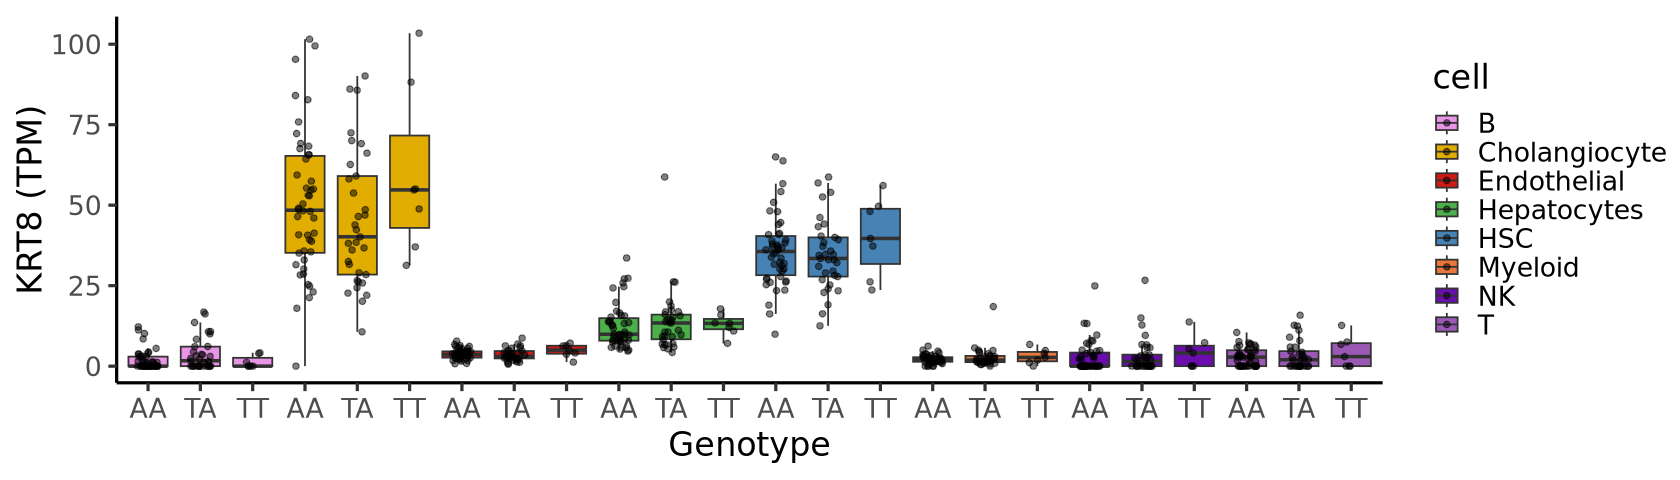

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


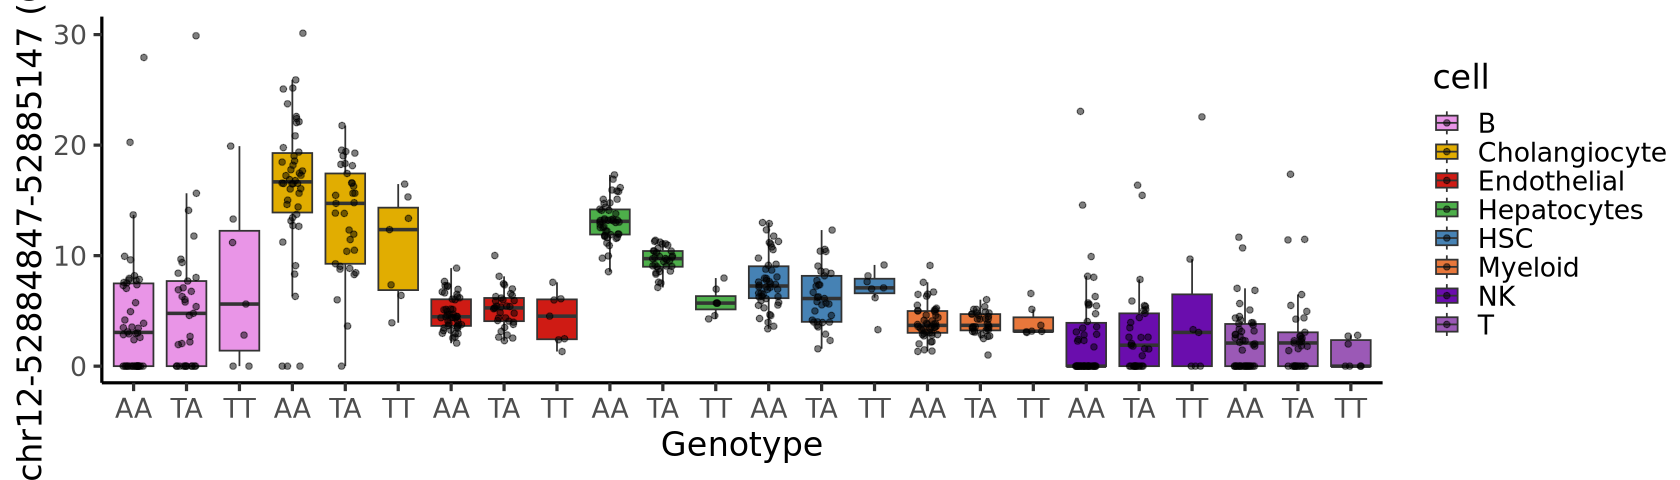

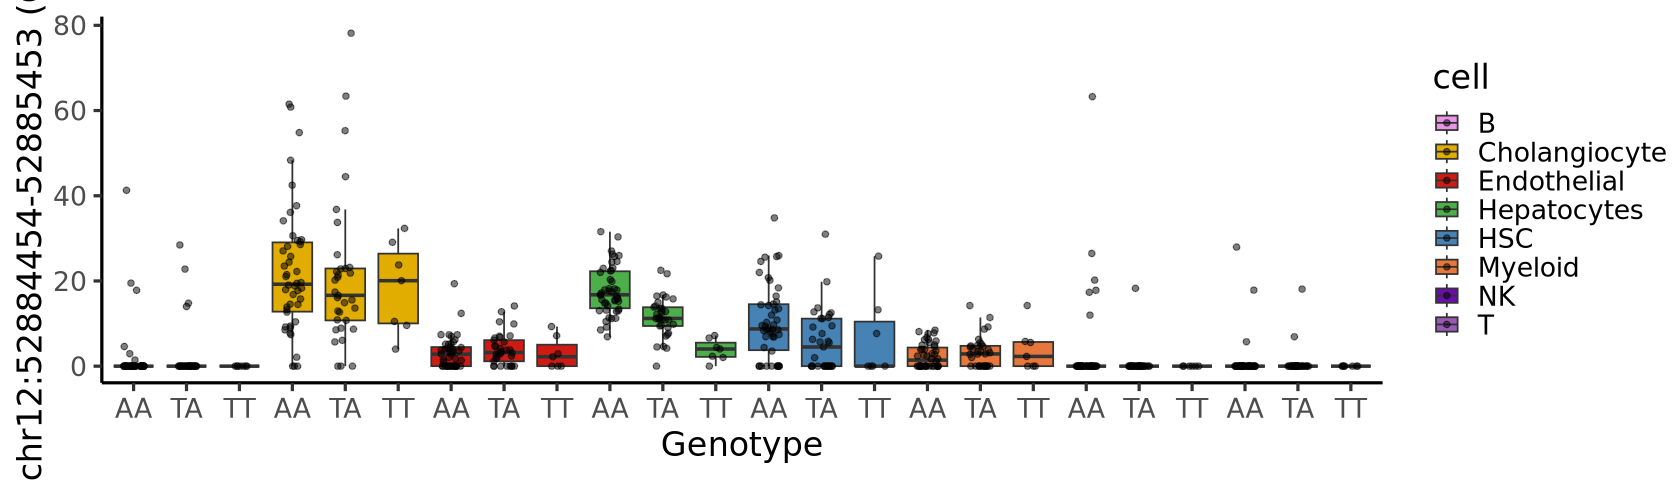

In [57]:
options(repr.plot.width=14, repr.plot.height=4)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
#dev.off()

In [31]:
options(repr.plot.width=14, repr.plot.height=4)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
dev.off()

pdf 
  2

pdf 
  2

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

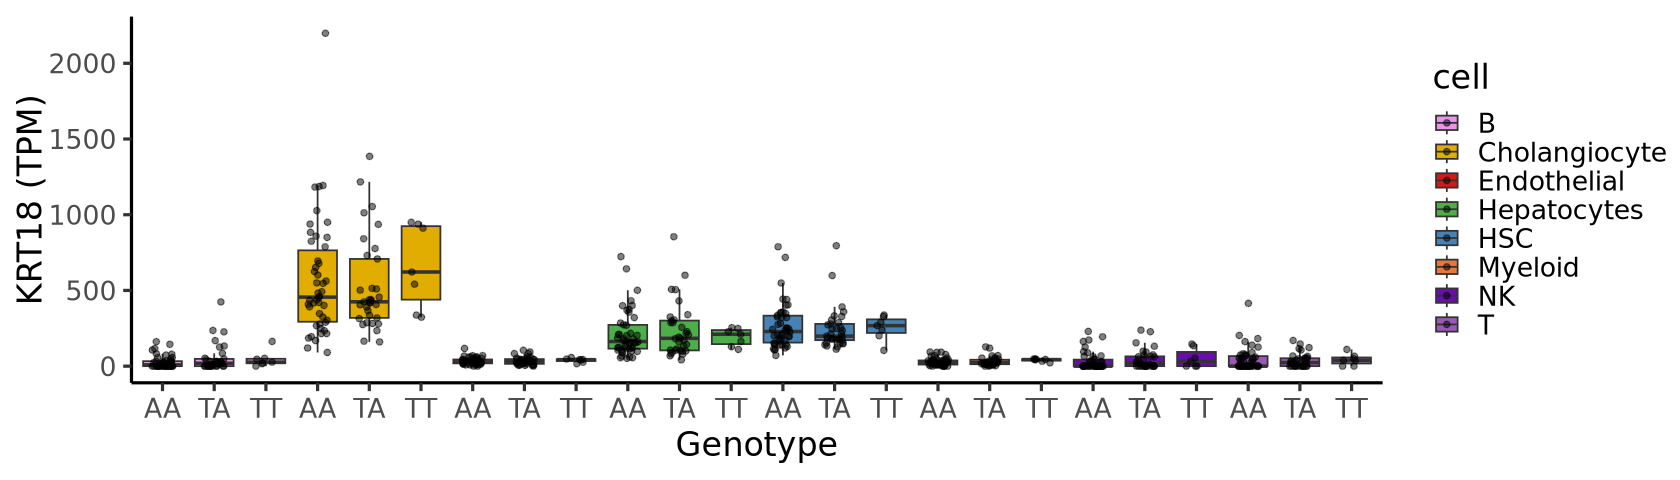

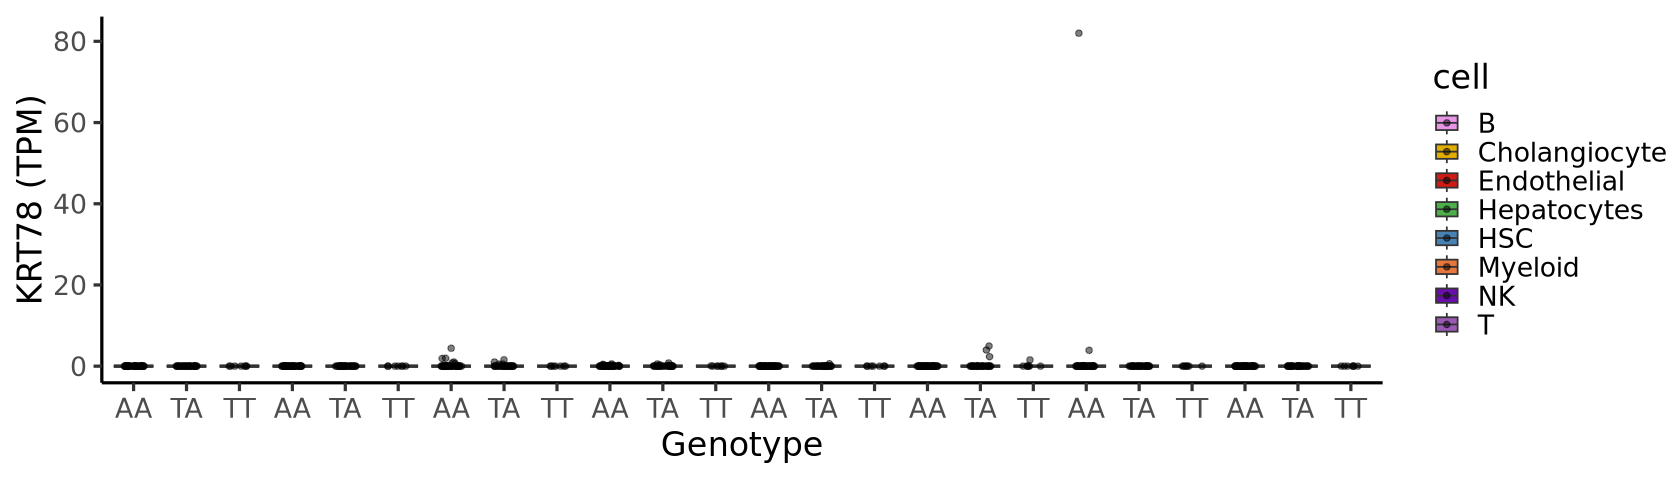

In [32]:
options(repr.plot.width=14, repr.plot.height=4)

qtl.boxplot('KRT18',variant, vcf.df, 
                TPM, celltype_colors, 'TPM')
qtl.boxplot('KRT78',variant, vcf.df, 
                TPM, celltype_colors, 'TPM')

# Locus Zoom

In [33]:
eqtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == gene)

dim(eqtl.res)
head(eqtl.res)

Rows: 4408979 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (7): start_distance, af, ma_samples, ma_count, pval_nominal, slope, slop...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4595    9

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KRT8,rs73094745,-999294,0.06395349,10,11,0.2656368,-0.24896036,0.2212881
KRT8,rs4761839,-996755,0.30232558,39,52,0.5522931,-0.08129487,0.1359124
KRT8,rs7962469,-995479,0.51162790,60,84,0.5751437,-0.07593316,0.1346370
KRT8,rs11610143,-994667,0.30232558,39,52,0.5522931,-0.08129487,0.1359124
KRT8,rs11612312,-994650,0.30232558,39,52,0.5522931,-0.08129487,0.1359124
KRT8,rs79583832,-991499,0.30232558,39,52,0.5522931,-0.08129487,0.1359124


In [34]:
eqtl.res$snp.id <- rownames(vcf.df[match(eqtl.res$variant_id, vcf.df$ID),])
eqtl.res$pos <- as.numeric(str_split(eqtl.res$snp.id, ':', simplify=T)[,2])

dim(eqtl.res)
head(eqtl.res)

[1] 4595   11

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
KRT8,rs73094745,-999294,0.06395349,10,11,0.2656368,-0.24896036,0.2212881,chr12:51950660:T:C,51950660
KRT8,rs4761839,-996755,0.30232558,39,52,0.5522931,-0.08129487,0.1359124,chr12:51953199:G:A,51953199
KRT8,rs7962469,-995479,0.51162790,60,84,0.5751437,-0.07593316,0.1346370,chr12:51954475:A:G,51954475
KRT8,rs11610143,-994667,0.30232558,39,52,0.5522931,-0.08129487,0.1359124,chr12:51955287:C:G,51955287
KRT8,rs11612312,-994650,0.30232558,39,52,0.5522931,-0.08129487,0.1359124,chr12:51955304:T:C,51955304
KRT8,rs79583832,-991499,0.30232558,39,52,0.5522931,-0.08129487,0.1359124,chr12:51958455:CA:C,51958455


In [35]:
ATAC.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == atac.feat)

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

Rows: 106798256 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4589   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr12-52884847-52885147,rs61914017,-999634,-999933,0.05232558,8,9,0.3286775,0.2947349,0.2989599
chr12-52884847-52885147,rs9669659,-999092,-999391,0.05813953,8,10,0.2570293,0.3276308,0.2859431
chr12-52884847-52885147,rs76585712,-998703,-999002,0.06395349,10,11,0.4337324,0.2675792,0.3392150
chr12-52884847-52885147,rs12231976,-998237,-998536,0.13372093,20,23,0.2368057,0.2656088,0.2219781
chr12-52884847-52885147,rs771994,-997611,-997910,0.25000000,37,43,0.3946128,0.1542587,0.1797338
chr12-52884847-52885147,rs771995,-997597,-997896,0.25000000,37,43,0.3946128,0.1542587,0.1797338


In [36]:
ATAC.qtl.res$snp.id <- rownames(vcf.df[match(ATAC.qtl.res$variant_id, vcf.df$ID),])
ATAC.qtl.res$pos <- as.numeric(str_split(ATAC.qtl.res$snp.id, ':', simplify=T)[,2])

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

[1] 4589   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr12-52884847-52885147,rs61914017,-999634,-999933,0.05232558,8,9,0.3286775,0.2947349,0.2989599,chr12:51885214:A:G,51885214
chr12-52884847-52885147,rs9669659,-999092,-999391,0.05813953,8,10,0.2570293,0.3276308,0.2859431,chr12:51885756:G:A,51885756
chr12-52884847-52885147,rs76585712,-998703,-999002,0.06395349,10,11,0.4337324,0.2675792,0.3392150,chr12:51886145:C:T,51886145
chr12-52884847-52885147,rs12231976,-998237,-998536,0.13372093,20,23,0.2368057,0.2656088,0.2219781,chr12:51886611:C:T,51886611
chr12-52884847-52885147,rs771994,-997611,-997910,0.25000000,37,43,0.3946128,0.1542587,0.1797338,chr12:51887237:G:T,51887237
chr12-52884847-52885147,rs771995,-997597,-997896,0.25000000,37,43,0.3946128,0.1542587,0.1797338,chr12:51887251:C:T,51887251


In [37]:
H3K27ac.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == ac.feat)

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

Rows: 51521345 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4590   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr12:52884454-52885453,rs706830,-999893,-1000891,0.40697673,55,70,0.06385723,0.3090132,0.1632612
chr12:52884454-52885453,rs61914017,-999241,-1000239,0.05232558,8,9,0.68804093,-0.1345097,0.3331734
chr12:52884454-52885453,rs9669659,-998699,-999697,0.05813953,8,10,0.14260245,0.5038155,0.3385212
chr12:52884454-52885453,rs76585712,-998310,-999308,0.06395349,10,11,0.44886114,0.2939405,0.3852557
chr12:52884454-52885453,rs12231976,-997844,-998842,0.13372093,20,23,0.05828492,0.4980709,0.2573484
chr12:52884454-52885453,rs771994,-997218,-998216,0.25000000,37,43,0.29080174,0.2217579,0.2078303


In [38]:
H3K27ac.qtl.res$snp.id <- rownames(vcf.df[match(H3K27ac.qtl.res$variant_id, vcf.df$ID),])
H3K27ac.qtl.res$pos <- as.numeric(str_split(H3K27ac.qtl.res$snp.id, ':', simplify=T)[,2])

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

[1] 4590   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr12:52884454-52885453,rs706830,-999893,-1000891,0.40697673,55,70,0.06385723,0.3090132,0.1632612,chr12:51884562:T:C,51884562
chr12:52884454-52885453,rs61914017,-999241,-1000239,0.05232558,8,9,0.68804093,-0.1345097,0.3331734,chr12:51885214:A:G,51885214
chr12:52884454-52885453,rs9669659,-998699,-999697,0.05813953,8,10,0.14260245,0.5038155,0.3385212,chr12:51885756:G:A,51885756
chr12:52884454-52885453,rs76585712,-998310,-999308,0.06395349,10,11,0.44886114,0.2939405,0.3852557,chr12:51886145:C:T,51886145
chr12:52884454-52885453,rs12231976,-997844,-998842,0.13372093,20,23,0.05828492,0.4980709,0.2573484,chr12:51886611:C:T,51886611
chr12:52884454-52885453,rs771994,-997218,-998216,0.25000000,37,43,0.29080174,0.2217579,0.2078303,chr12:51887237:G:T,51887237


In [39]:
region <- c(52840000,53040000)
region[2]-region[1]

[1] 2e+05

pdf 
  2

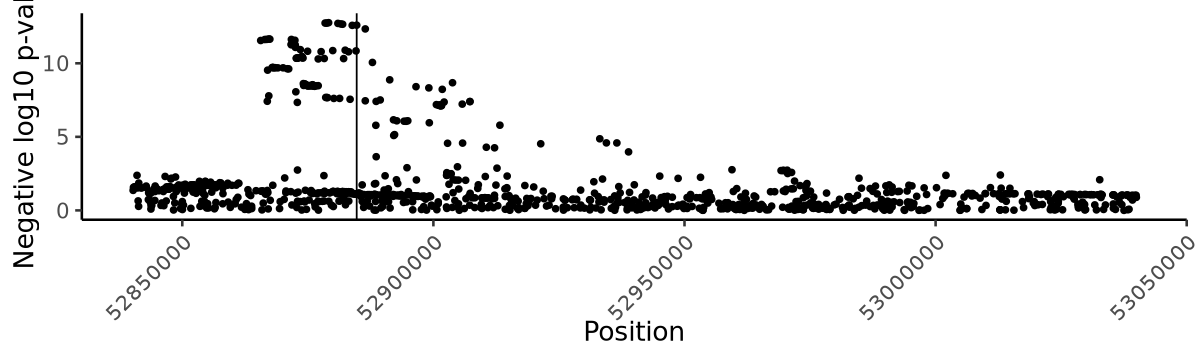

In [43]:
#chr12-52884847-52885147
options(repr.plot.width=10, repr.plot.height=3)
p1 <- ggplot(filter(ALT, chr.hg38 == chr & pos.hg38 > region[1] & pos.hg38 < region[2]), 
      aes(x=pos.hg38, y=-log10(P))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_GWAS_200kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 4184 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 4184 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

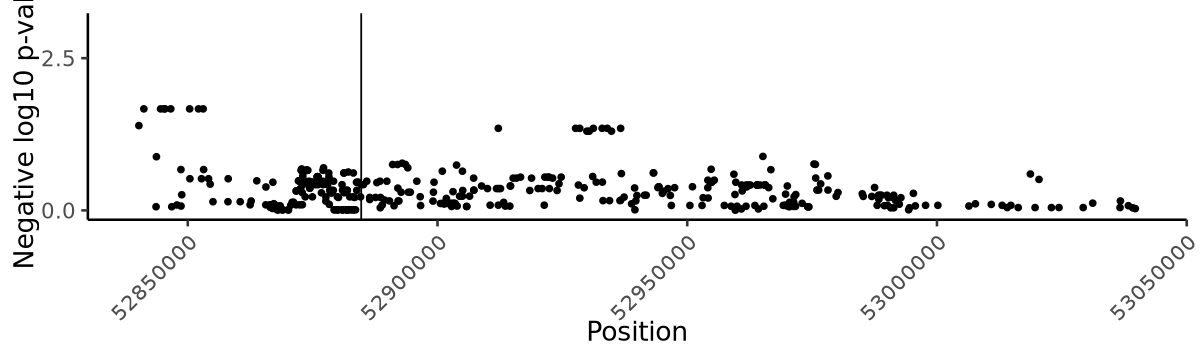

In [44]:
p1 <- ggplot(eqtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))
p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_eQTL_200kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 4178 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 4178 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

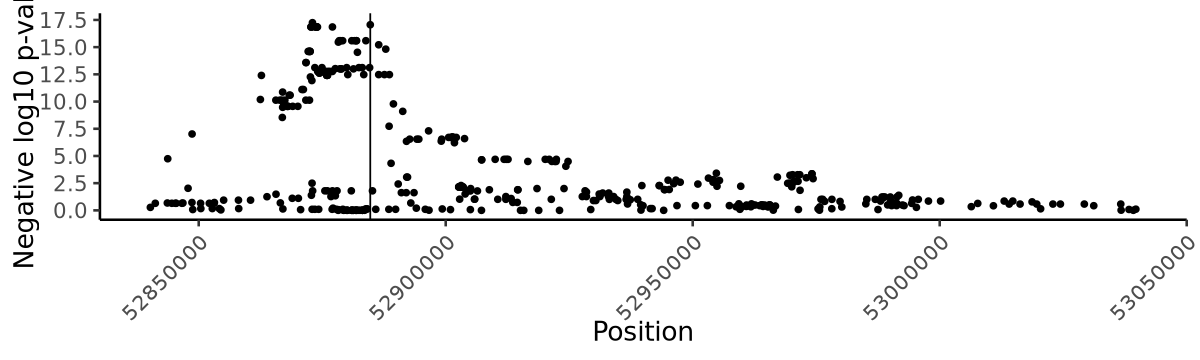

In [45]:
p1 <- ggplot(ATAC.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_caQTL_200kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 4179 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 4179 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

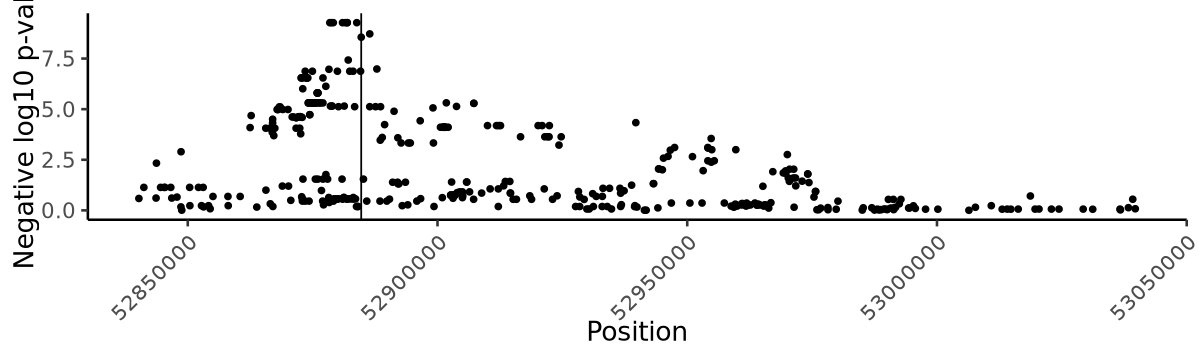

In [46]:
p1 <- ggplot(H3K27ac.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_H3K27acQTL_200kb_v2.pdf'), width=10, height=3)
p1
dev.off()

pdf 
  2

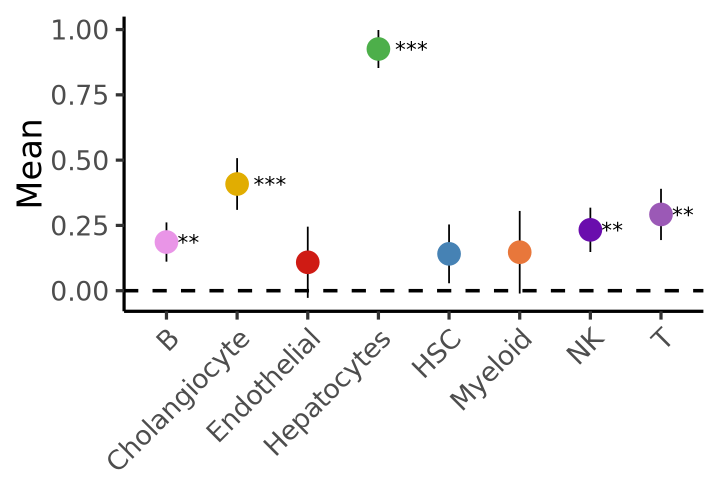

In [39]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(caQTL.post.mean[str_detect(rownames(caQTL.post.mean), atac.feat),]), 
          sd=unlist(caQTL.post.sd[str_detect(rownames(caQTL.post.sd), atac.feat),]),
          ct=colnames(caQTL.post.mean),
          lfsr=unlist(caQTL.post.lfsr[str_detect(rownames(caQTL.post.lfsr), atac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_caQTL_',gene,'.pdf'), width=6, height=4)
p1
dev.off()

pdf 
  2

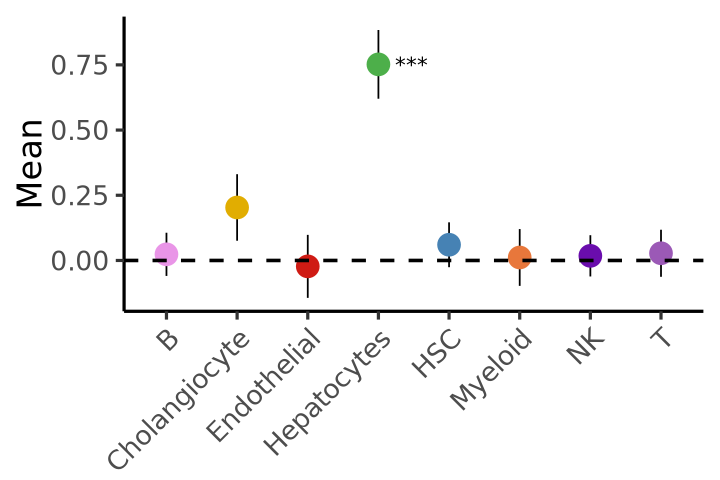

In [40]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(H3K27acQTL.post.mean[str_detect(rownames(H3K27acQTL.post.mean), ac.feat),]), 
          sd=unlist(H3K27acQTL.post.sd[str_detect(rownames(H3K27acQTL.post.sd), ac.feat),]),
          ct=colnames(H3K27acQTL.post.mean),
          lfsr=unlist(H3K27acQTL.post.lfsr[str_detect(rownames(H3K27acQTL.post.lfsr), ac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip()

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_H3K27acQTL_',gene,'_flipped.pdf'), width=6, height=4)
p1
dev.off()

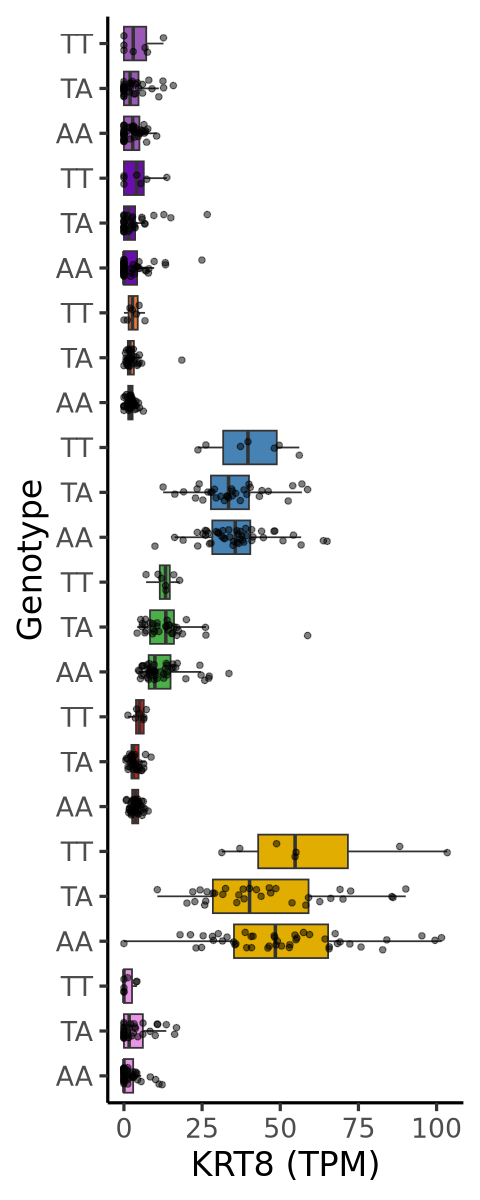

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


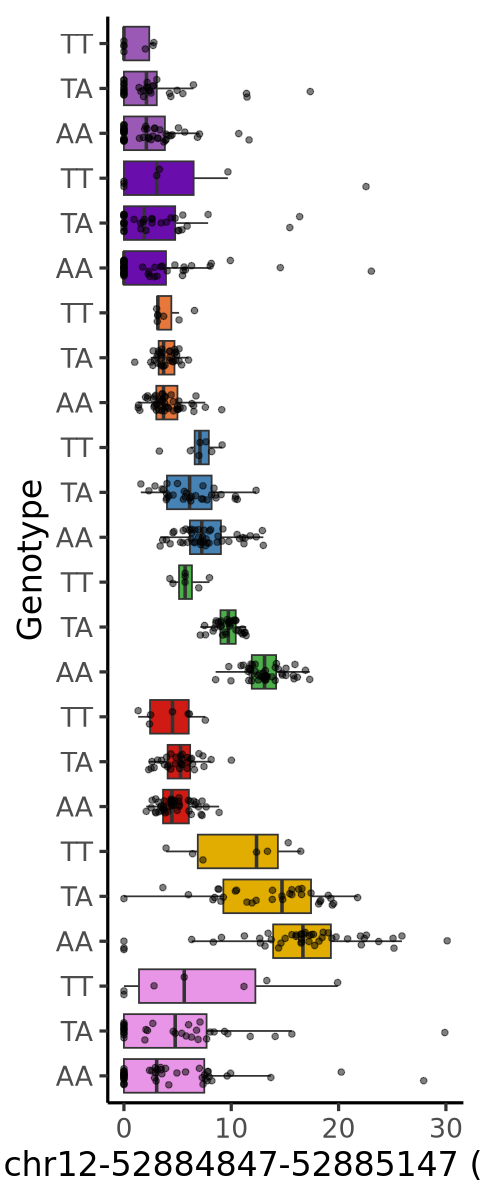

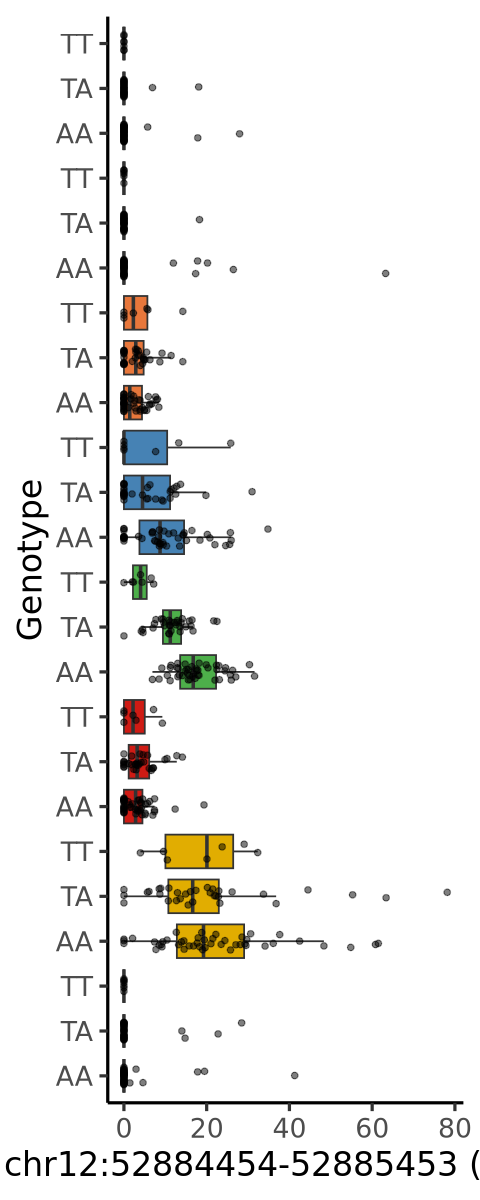

In [70]:
options(repr.plot.width=4, repr.plot.height=10)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
#dev.off()

In [71]:
options(repr.plot.width=4, repr.plot.height=10)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
dev.off()

pdf 
  2

pdf 
  2

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

# PPP1R3B

In [8]:
gene <- 'PPP1R3B'
atac.feat <- 'chr8-9325934-9326177'
ac.feat <- 'chr8:9325503-9326502'
variant <- 'rs4841132'
variant.pos <- 9326154
chr <- 8

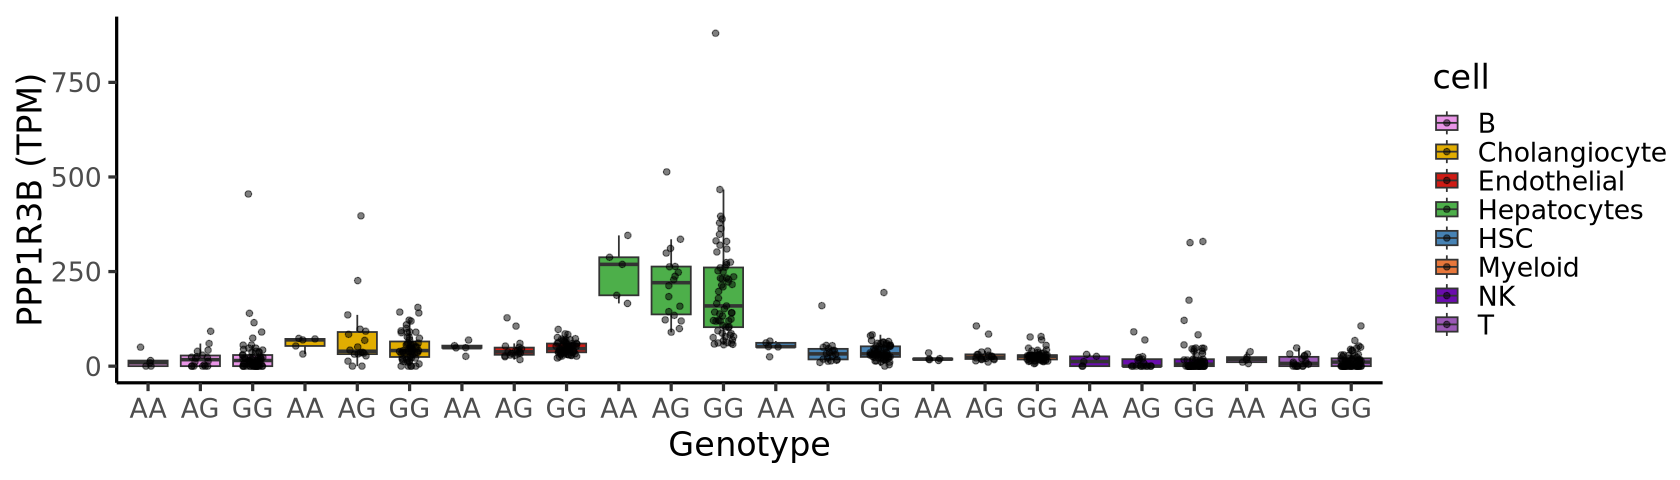

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


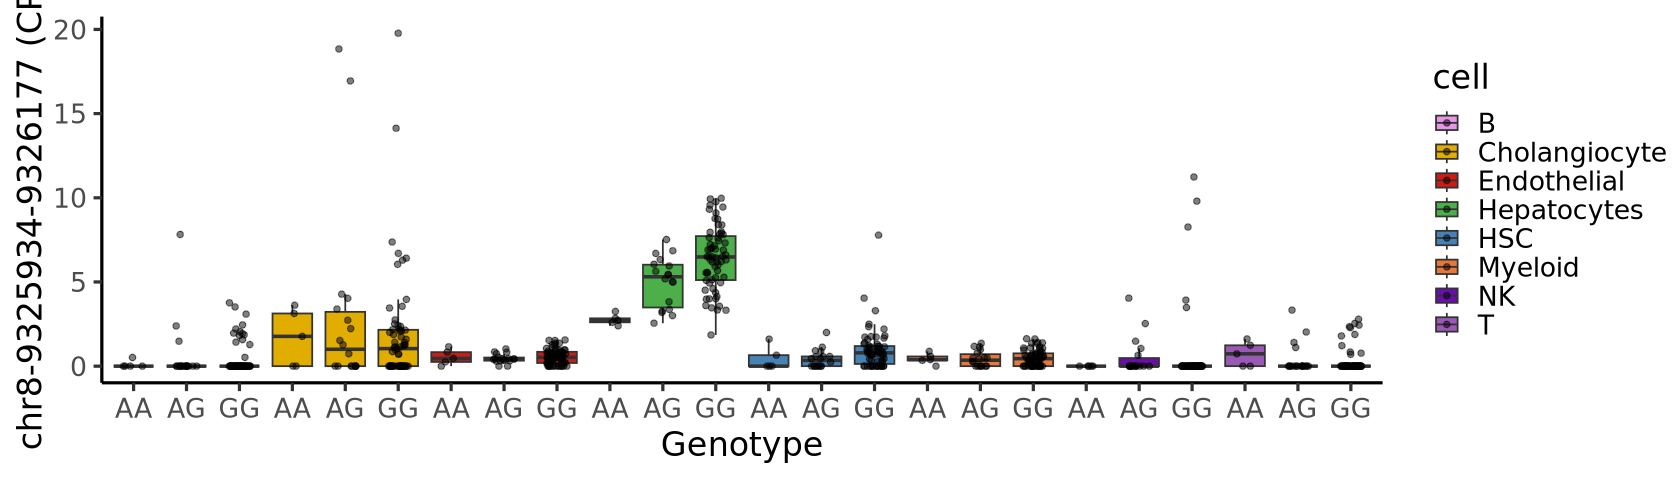

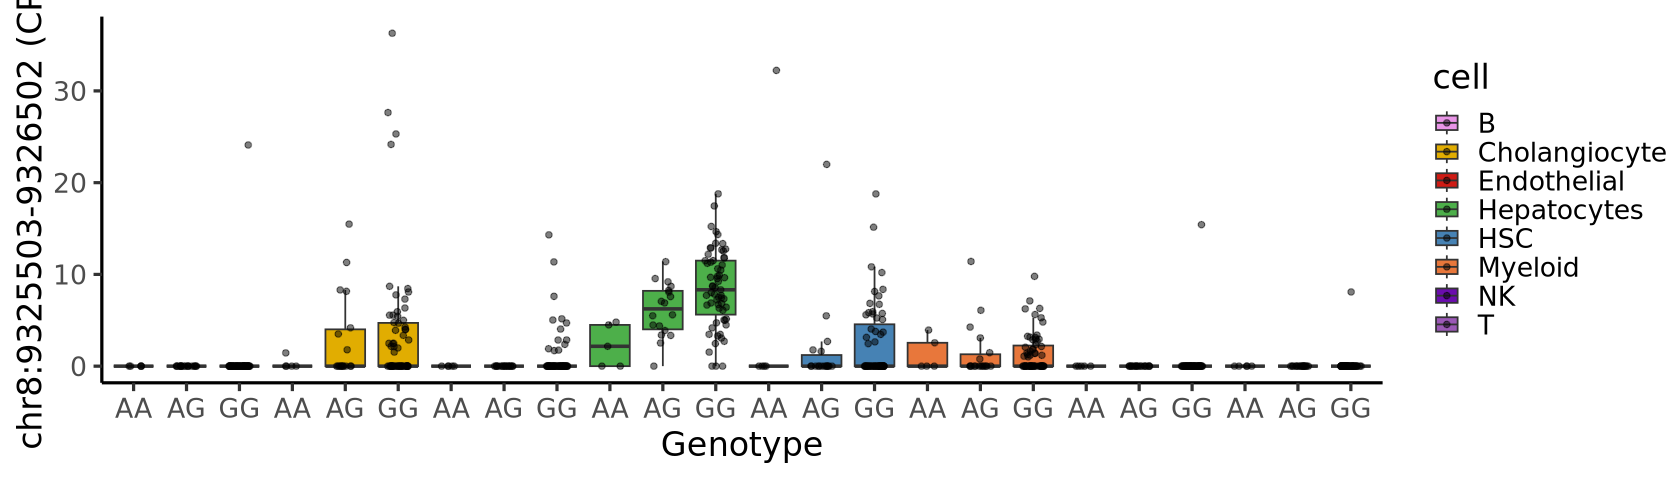

In [73]:
options(repr.plot.width=14, repr.plot.height=4)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
#dev.off()

In [74]:
options(repr.plot.width=14, repr.plot.height=4)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
dev.off()

pdf 
  2

pdf 
  2

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

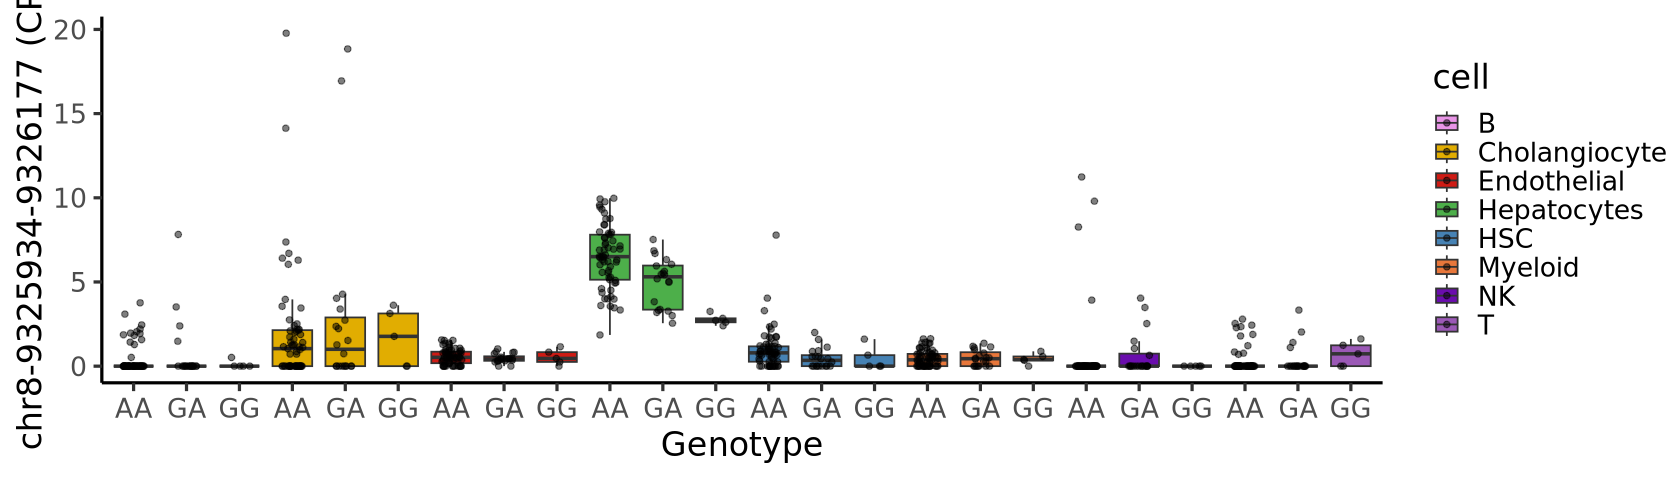

In [65]:
options(repr.plot.width=14, repr.plot.height=4)
qtl.boxplot(atac.feat,variant, vcf.df, 
                CPM.ATAC, celltype_colors, 'CPM')

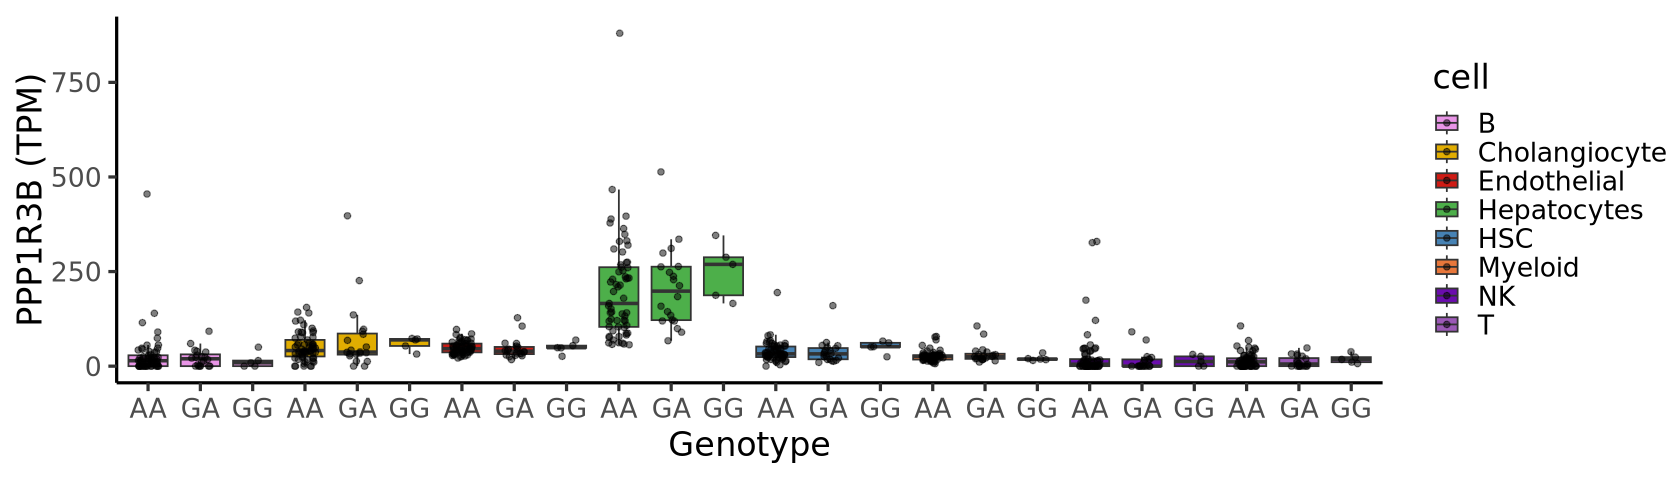

In [25]:
options(repr.plot.width=14, repr.plot.height=4)

#pdf('/nfs/lab/welison/Liver/Plots/241220_WE_KRT8_eQTL_boxplot.pdf', width=14, heigh=4)
qtl.boxplot('PPP1R3B',variant, vcf.df, 
                TPM, celltype_colors, 'TPM')
##dev.off()
##pdf('/nfs/lab/welison/Liver/Plots/241220_WE_KRT8_caQTL_boxplot.pdf', width=14, heigh=4)
#qtl.boxplot('chr12-52884847-52885147','rs4919741', vcf.df, 
#                CPM.ATAC, celltype_colors, 'CPM')
##dev.off()
##pdf('/nfs/lab/welison/Liver/Plots/241220_WE_KRT8_H3K27acQTL_boxplot.pdf', width=14, heigh=4)
#qtl.boxplot('chr12:52884454-52885453','rs4919741', vcf.df, 
#                CPM.H3K27ac, celltype_colors, 'CPM')
##dev.off()

# Locus Zoom

In [75]:
eqtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == gene)

dim(eqtl.res)
head(eqtl.res)

Rows: 3162218 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (7): start_distance, af, ma_samples, ma_count, pval_nominal, slope, slop...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 5630    9

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PPP1R3B,rs712253,-905314,0.2616279,39,45,0.10087587,0.28352118,0.1698038
PPP1R3B,rs11250200,-904352,0.5872093,51,71,0.65679085,-0.06639655,0.1485819
PPP1R3B,rs793753,-903737,0.2674419,40,46,0.07091552,0.31186908,0.1692126
PPP1R3B,rs17594065,-903691,0.2500000,38,43,0.15384091,0.25199145,0.1741712
PPP1R3B,rs17594093,-902690,0.2325581,35,40,0.28924793,0.18950327,0.1770241
PPP1R3B,rs58532302,-901511,0.4011628,49,69,0.15847582,-0.19283770,0.1348152


In [76]:
eqtl.res$snp.id <- rownames(vcf.df[match(eqtl.res$variant_id, vcf.df$ID),])
eqtl.res$pos <- as.numeric(str_split(eqtl.res$snp.id, ':', simplify=T)[,2])

dim(eqtl.res)
head(eqtl.res)

[1] 5630   11

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
PPP1R3B,rs712253,-905314,0.2616279,39,45,0.10087587,0.28352118,0.1698038,chr8:8246260:C:T,8246260
PPP1R3B,rs11250200,-904352,0.5872093,51,71,0.65679085,-0.06639655,0.1485819,chr8:8247222:C:G,8247222
PPP1R3B,rs793753,-903737,0.2674419,40,46,0.07091552,0.31186908,0.1692126,chr8:8247837:T:G,8247837
PPP1R3B,rs17594065,-903691,0.2500000,38,43,0.15384091,0.25199145,0.1741712,chr8:8247883:T:C,8247883
PPP1R3B,rs17594093,-902690,0.2325581,35,40,0.28924793,0.18950327,0.1770241,chr8:8248884:G:T,8248884
PPP1R3B,rs58532302,-901511,0.4011628,49,69,0.15847582,-0.19283770,0.1348152,chr8:8250063:C:A,8250063


In [77]:
ATAC.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == atac.feat)

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

Rows: 102279992 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 6134   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr8-9325934-9326177,rs2945899,-999768,-1000010,0.2965116,44,51,0.8689031,0.02487333,0.1499715
chr8-9325934-9326177,rs2979208,-997284,-997526,0.2732558,41,47,0.4146085,-0.13017389,0.1583108
chr8-9325934-9326177,rs2976910,-997114,-997356,0.2848837,43,49,0.4771505,-0.11350703,0.1585352
chr8-9325934-9326177,rs2945900,-996632,-996874,0.2500000,39,43,0.5085756,-0.11272033,0.1693604
chr8-9325934-9326177,rs2979210,-995949,-996191,0.2441860,38,42,0.4852524,-0.11967274,0.1702785
chr8-9325934-9326177,rs2945901,-995901,-996143,0.2441860,38,42,0.4852524,-0.11967274,0.1702785


In [78]:
ATAC.qtl.res$snp.id <- rownames(vcf.df[match(ATAC.qtl.res$variant_id, vcf.df$ID),])
ATAC.qtl.res$pos <- as.numeric(str_split(ATAC.qtl.res$snp.id, ':', simplify=T)[,2])

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

[1] 6134   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr8-9325934-9326177,rs2945899,-999768,-1000010,0.2965116,44,51,0.8689031,0.02487333,0.1499715,chr8:8326167:T:C,8326167
chr8-9325934-9326177,rs2979208,-997284,-997526,0.2732558,41,47,0.4146085,-0.13017389,0.1583108,chr8:8328651:T:C,8328651
chr8-9325934-9326177,rs2976910,-997114,-997356,0.2848837,43,49,0.4771505,-0.11350703,0.1585352,chr8:8328821:A:T,8328821
chr8-9325934-9326177,rs2945900,-996632,-996874,0.2500000,39,43,0.5085756,-0.11272033,0.1693604,chr8:8329303:G:T,8329303
chr8-9325934-9326177,rs2979210,-995949,-996191,0.2441860,38,42,0.4852524,-0.11967274,0.1702785,chr8:8329986:A:G,8329986
chr8-9325934-9326177,rs2945901,-995901,-996143,0.2441860,38,42,0.4852524,-0.11967274,0.1702785,chr8:8330034:T:C,8330034


In [79]:
H3K27ac.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == ac.feat)

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

Rows: 46962221 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 6135   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr8:9325503-9326502,rs2203826,-999618,-1000616,0.04651163,8,8,0.9011585,-0.05381530,0.4312320
chr8:9325503-9326502,rs2945899,-999337,-1000335,0.29651162,44,51,0.6861006,0.05943257,0.1462492
chr8:9325503-9326502,rs2979208,-996853,-997851,0.27325583,41,47,0.5097091,0.09631896,0.1451070
chr8:9325503-9326502,rs2976910,-996683,-997681,0.28488370,43,49,0.7580013,0.04460953,0.1440398
chr8:9325503-9326502,rs2945900,-996201,-997199,0.25000000,39,43,0.6073281,0.07980661,0.1543739
chr8:9325503-9326502,rs2979210,-995518,-996516,0.24418604,38,42,0.5953902,0.08260580,0.1546149


In [80]:
H3K27ac.qtl.res$snp.id <- rownames(vcf.df[match(H3K27ac.qtl.res$variant_id, vcf.df$ID),])
H3K27ac.qtl.res$pos <- as.numeric(str_split(H3K27ac.qtl.res$snp.id, ':', simplify=T)[,2])

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

[1] 6135   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr8:9325503-9326502,rs2203826,-999618,-1000616,0.04651163,8,8,0.9011585,-0.05381530,0.4312320,chr8:8325886:T:C,8325886
chr8:9325503-9326502,rs2945899,-999337,-1000335,0.29651162,44,51,0.6861006,0.05943257,0.1462492,chr8:8326167:T:C,8326167
chr8:9325503-9326502,rs2979208,-996853,-997851,0.27325583,41,47,0.5097091,0.09631896,0.1451070,chr8:8328651:T:C,8328651
chr8:9325503-9326502,rs2976910,-996683,-997681,0.28488370,43,49,0.7580013,0.04460953,0.1440398,chr8:8328821:A:T,8328821
chr8:9325503-9326502,rs2945900,-996201,-997199,0.25000000,39,43,0.6073281,0.07980661,0.1543739,chr8:8329303:G:T,8329303
chr8:9325503-9326502,rs2979210,-995518,-996516,0.24418604,38,42,0.5953902,0.08260580,0.1546149,chr8:8329986:A:G,8329986


In [81]:
region <- c(9100000,9400000)
region[2]-region[1]

[1] 3e+05

In [82]:
region

[1] 9100000 9400000

pdf 
  2

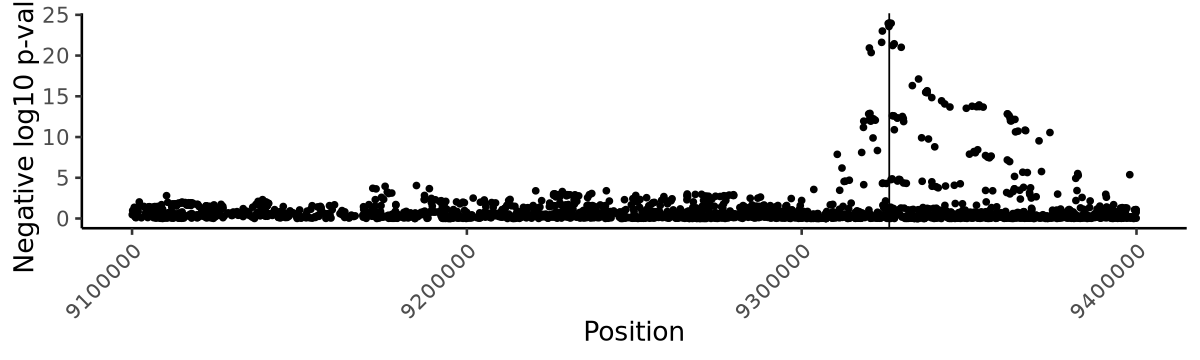

In [83]:
#chr12-52884847-52885147
options(repr.plot.width=10, repr.plot.height=3)
p1 <- ggplot(filter(ALT, chr.hg38 == chr & pos.hg38 > region[1] & pos.hg38 < region[2]), 
      aes(x=pos.hg38, y=-log10(P))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_GWAS.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 4792 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 4792 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

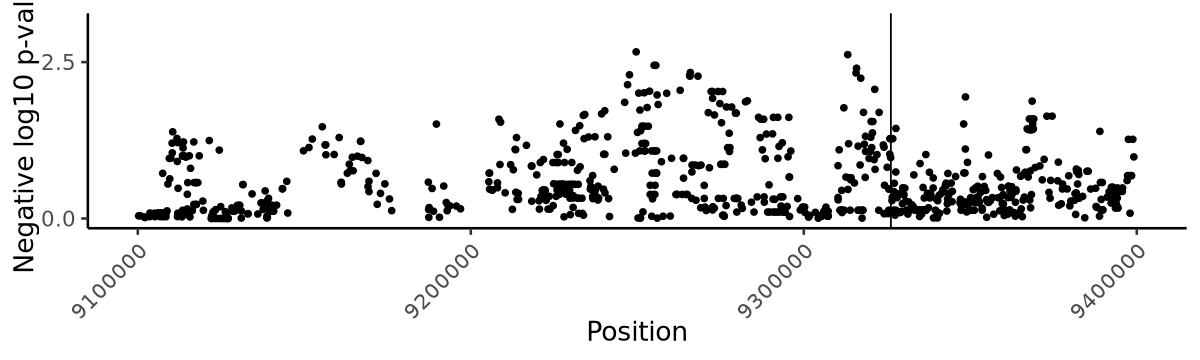

In [84]:
p1 <- ggplot(eqtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))
p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_eQTL.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 5296 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 5296 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

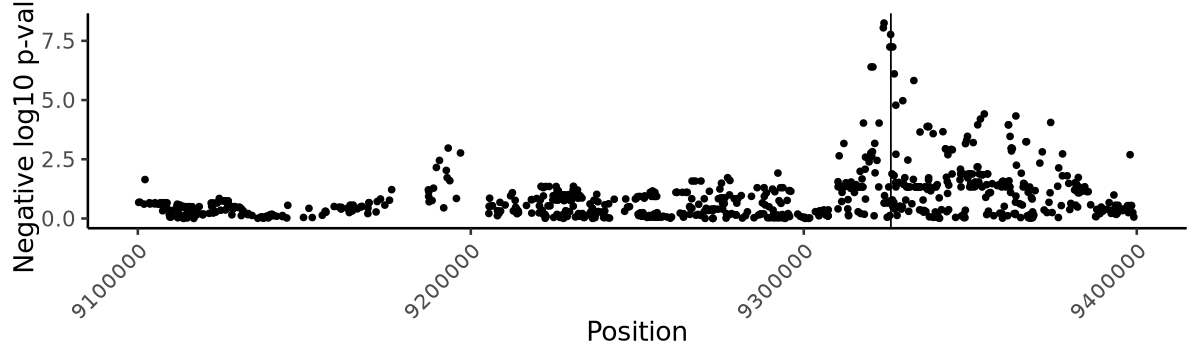

In [85]:
p1 <- ggplot(ATAC.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_caQTL.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 5297 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 5297 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

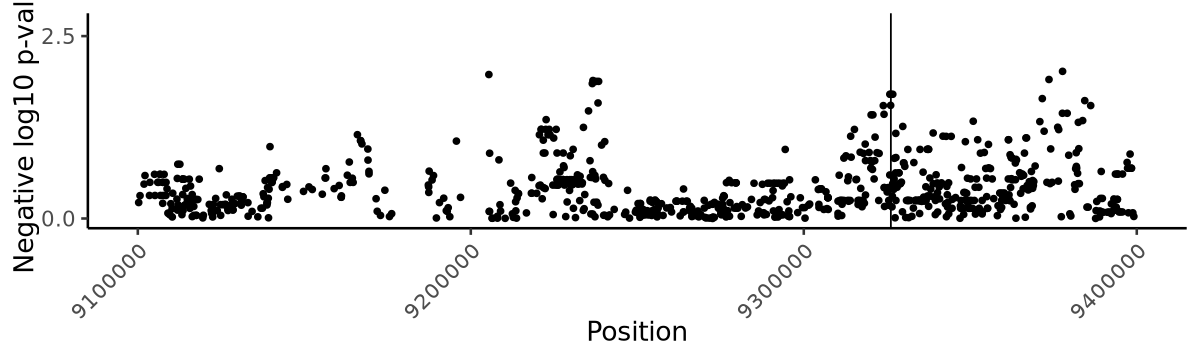

In [86]:
p1 <- ggplot(H3K27ac.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_H3K27acQTL.pdf'), width=10, height=3)
p1
dev.off()

pdf 
  2

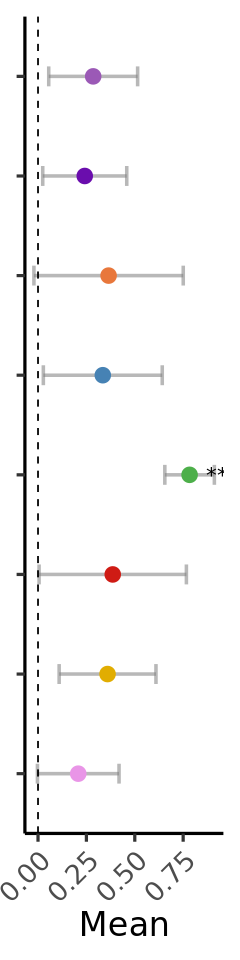

In [87]:
options(repr.plot.width=2, repr.plot.height=8)

p1 <- data.frame(mean=unlist(caQTL.post.mean[str_detect(rownames(caQTL.post.mean), atac.feat),]), 
          sd=unlist(caQTL.post.sd[str_detect(rownames(caQTL.post.sd), atac.feat),]),
          ct=colnames(caQTL.post.mean),
          lfsr=unlist(caQTL.post.lfsr[str_detect(rownames(caQTL.post.lfsr), atac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high, alpha=.4, color='grey'), height = 0.2, size=1) +
        geom_point(aes(color=ct), size=4) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1),
             axis.text.y = element_blank()) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8) +
        geom_text(aes(hjust=-0.5, size=200)) 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_caQTL_',gene,'_flipped.pdf'), width=2, height=8)
p1
dev.off()

pdf 
  2

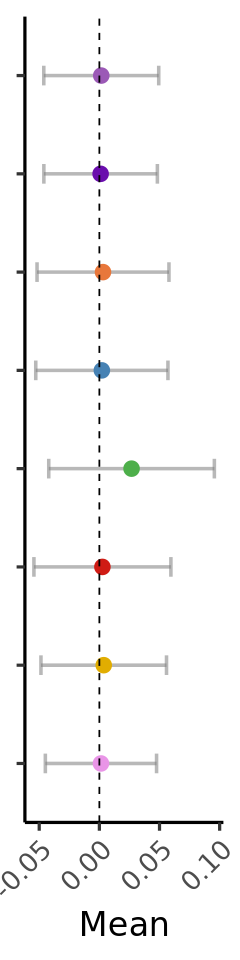

In [88]:
options(repr.plot.width=2, repr.plot.height=8)

p1 <- data.frame(mean=unlist(H3K27acQTL.post.mean[str_detect(rownames(H3K27acQTL.post.mean), ac.feat),]), 
          sd=unlist(H3K27acQTL.post.sd[str_detect(rownames(H3K27acQTL.post.sd), ac.feat),]),
          ct=colnames(H3K27acQTL.post.mean),
          lfsr=unlist(H3K27acQTL.post.lfsr[str_detect(rownames(H3K27acQTL.post.lfsr), ac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high, alpha=.4, color='grey'), height = 0.2, size=1) +
        geom_point(aes(color=ct), size=4) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1),
             axis.text.y = element_blank()) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8) +
        geom_text(aes(hjust=-0.5, size=200)) 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_H3K27acQTL_',gene,'_flipped.pdf'), width=2, height=8)
p1
dev.off()

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


pdf 
  2

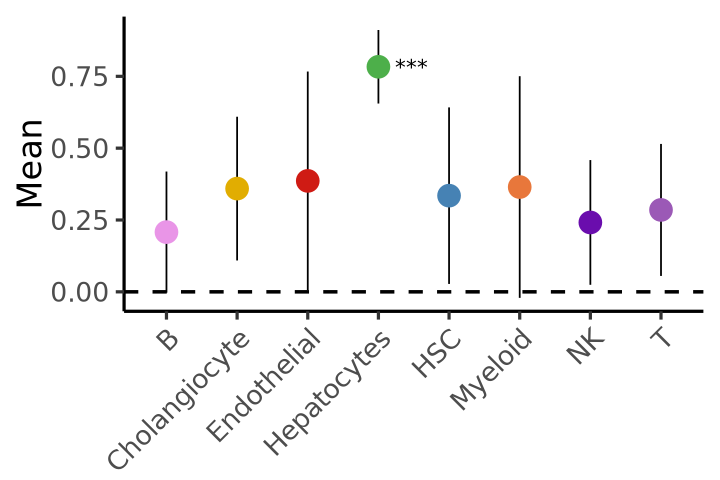

In [9]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(caQTL.post.mean[str_detect(rownames(caQTL.post.mean), atac.feat),]), 
          sd=unlist(caQTL.post.sd[str_detect(rownames(caQTL.post.sd), atac.feat),]),
          ct=colnames(caQTL.post.mean),
          lfsr=unlist(caQTL.post.lfsr[str_detect(rownames(caQTL.post.lfsr), atac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_caQTL_',gene,'.pdf'), width=6, height=4)
p1
dev.off()

pdf 
  2

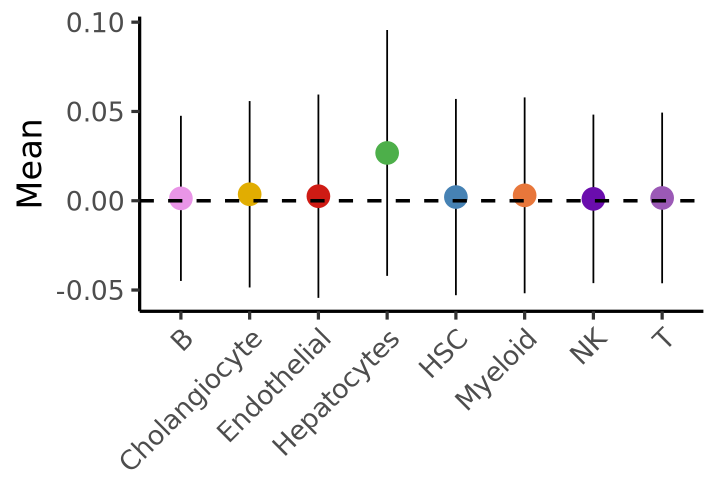

In [10]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(H3K27acQTL.post.mean[str_detect(rownames(H3K27acQTL.post.mean), ac.feat),]), 
          sd=unlist(H3K27acQTL.post.sd[str_detect(rownames(H3K27acQTL.post.sd), ac.feat),]),
          ct=colnames(H3K27acQTL.post.mean),
          lfsr=unlist(H3K27acQTL.post.lfsr[str_detect(rownames(H3K27acQTL.post.lfsr), ac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip()

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_H3K27acQTL_',gene,'_flipped.pdf'), width=6, height=4)
p1
dev.off()

Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 156 rows containing missing values or values outside the scale range (`geom_point()`).”


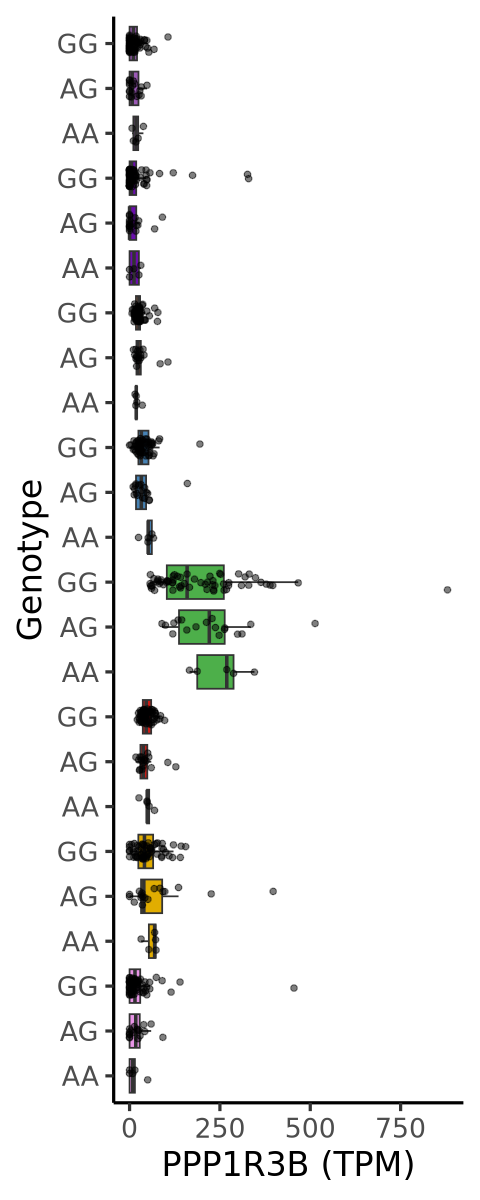

Warning message:
“Removed 9 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 259 rows containing missing values or values outside the scale range (`geom_point()`).”


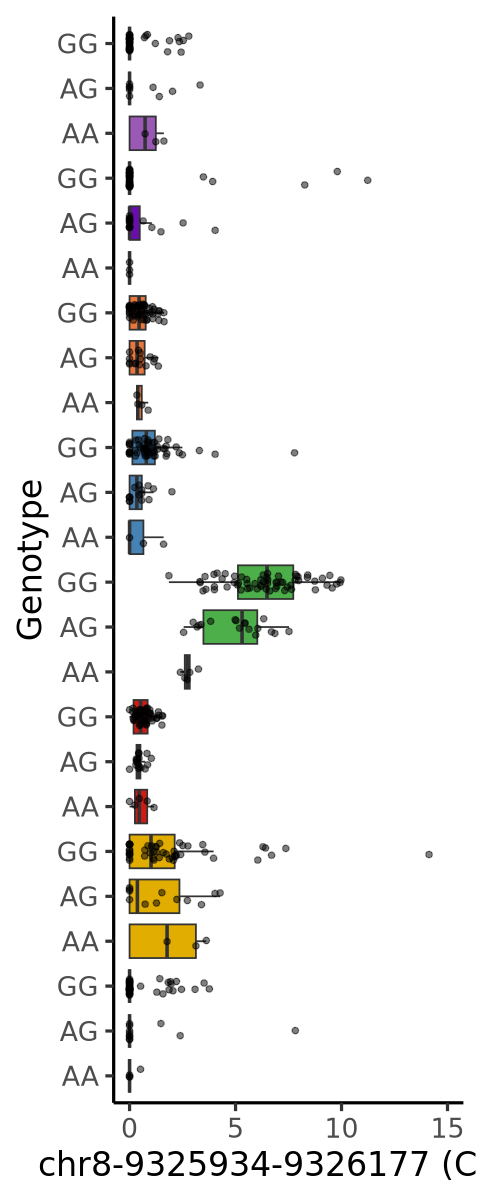

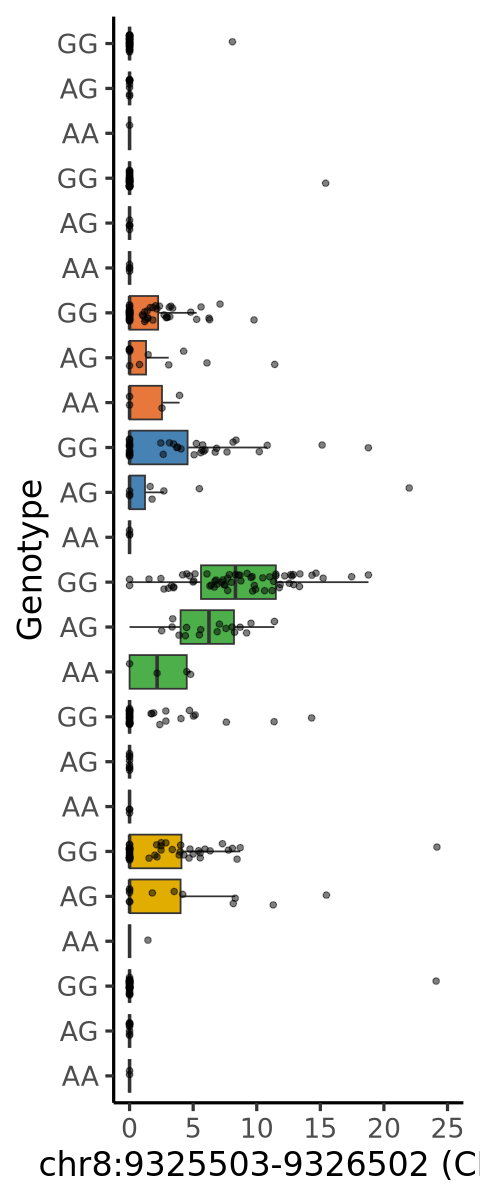

In [91]:
options(repr.plot.width=4, repr.plot.height=10)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM', ylims = c(0,15))
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM', ylims = c(0,25))
#dev.off()

In [92]:
options(repr.plot.width=4, repr.plot.height=10)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM', ylims = c(0,15))
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM', ylims = c(0,25))
dev.off()

pdf 
  2

Warning message:
“Removed 3 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 176 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

Warning message:
“Removed 9 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 255 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

In [93]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,21000291,1121.6,42553887,2272.7,42553887,2272.7
Vcells,1424504449,10868.2,2184958023,16670.0,2184958023,16670.0


In [20]:
coloc.res

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2866,7.785105e-09,5.311408e-04,1.782465e-06,0.120730410,0.8787367,Hepatocytes,ATAC,chr1-16179136-16179436,rs6656611,6.831334e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2832,7.832685e-07,3.756671e-04,1.793359e-04,0.085097785,0.9143464,Hepatocytes,ATAC,chr1-16189049-16189288,rs6656611,3.613621e-09,16189310,rs1497406,1.458e-08,16178825,0.823
2825,4.295586e-14,2.657291e-04,9.835105e-12,0.059901085,0.9398332,Hepatocytes,ATAC,chr1-16189980-16190280,rs6690317,2.161590e-13,16190090,rs1497406,1.458e-08,16178825,0.823
2439,4.226498e-35,2.134257e-11,3.782529e-26,0.018118780,0.9818812,Hepatocytes,ATAC,chr11-61820741-61821041,rs174536,1.015739e-17,61784455,rs174535,3.105e-15,61783884,0.978
3137,6.809861e-28,1.723499e-26,6.380127e-04,0.015163181,0.9841988,Hepatocytes,ATAC,chr11-94132939-94133200,rs11607757,1.160876e-08,94132981,rs7117339,2.256e-30,94137172,1.000
3759,1.174897e-33,8.672100e-09,2.153630e-26,0.158120960,0.8418790,Hepatocytes,ATAC,chr12-52884847-52885147,rs4919766,5.638330e-18,52873026,rs4919741,1.721e-13,52879136,0.899
3412,6.073097e-09,5.677144e-05,4.623425e-07,0.003325370,0.9966174,Hepatocytes,ATAC,chr14-24402430-24402730,rs11621792,4.463059e-10,24402720,rs11621792,1.114e-08,24402720,1.000
3192,1.294632e-30,1.454103e-05,2.214677e-27,0.023898695,0.9760868,Hepatocytes,ATAC,chr15-89803942-89804242,rs72754570,5.933149e-19,89805748,rs72754571,2.467e-09,89807657,0.862
2691,2.604753e-07,2.112140e-04,2.420459e-04,0.195465879,0.8040806,Hepatocytes,ATAC,chr19-4327651-4327951,rs4435380,1.567333e-10,4335872,rs3810367,3.505e-09,4342850,0.826


In [21]:
filter(coloc.res, gwas.lead=='rs7604422')

nsnps,PP.H0.abf,PP.H1.abf,PP.H2.abf,PP.H3.abf,PP.H4.abf,cell,modality,feature,qtl.lead,qtl.pval,qtl.pos,gwas.lead,gwas.pval,qtl.pos.1,r2
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>
2868,1.021755e-09,5.286654e-09,1.099240e-03,0.004693359,0.9942074,Hepatocytes,ATAC,chr2-232625035-232625335,rs2140773,1.370144e-07,232648465,rs7604422,1.238e-12,232645051,0.988
2857,1.544228e-10,5.086516e-09,1.661334e-04,0.004476894,0.9953570,Hepatocytes,ATAC,chr2-232630358-232630573,rs2140773,1.024331e-07,232648465,rs7604422,1.238e-12,232645051,0.988
2852,1.157110e-11,4.445423e-09,1.244859e-05,0.003786339,0.9962012,Hepatocytes,ATAC,chr2-232633413-232633713,rs11683367,1.774792e-08,232645301,rs7604422,1.238e-12,232645051,1.000
2850,6.122376e-14,5.194945e-09,6.586665e-08,0.004593496,0.9954064,Hepatocytes,ATAC,chr2-232634877-232635116,rs11689178,6.797369e-11,232645141,rs7604422,1.238e-12,232645051,0.956
2842,5.862667e-11,4.751358e-09,6.307260e-05,0.004115855,0.9958211,Hepatocytes,ATAC,chr2-232636795-232637095,rs7604422,8.428204e-08,232645051,rs7604422,1.238e-12,232645051,1.000
2837,7.803163e-18,4.506822e-09,8.394914e-12,0.003852448,0.9961475,Hepatocytes,ATAC,chr2-232642905-232643205,rs11683367,3.166449e-13,232645301,rs7604422,1.238e-12,232645051,1.000
2837,4.773806e-21,4.274958e-09,5.135826e-15,0.003602751,0.9963972,Hepatocytes,ATAC,chr2-232647251-232647551,rs11683367,5.906627e-14,232645301,rs7604422,1.238e-12,232645051,1.000
2837,3.401286e-11,6.493321e-09,3.659221e-05,0.005991769,0.9939716,Hepatocytes,ATAC,chr2-232649192-232649393,rs4973050,2.525626e-09,232649928,rs7604422,1.238e-12,232645051,0.947
2835,1.124735e-22,3.967666e-09,1.210029e-16,0.003271825,0.9967282,Hepatocytes,ATAC,chr2-232651647-232651947,rs7604422,4.459065e-15,232645051,rs7604422,1.238e-12,232645051,1.000


In [18]:
fine.mapping %>%
    filter(Chr==2 & Nominated.Gene == 'EFHD1')

CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,chr.hg38,end.hg38,start.hg38
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>
,rs11683367,rs7604422,2,233509761,C,A,0.408,-0.056,0.0065,1.23e-17,218595,48.93%,EFHD1,EFHD1,2,232645051,232645050
,rs11683367,rs11683367,2,233510011,C,T,0.402,-0.057,0.0066,6.38e-18,218595,45.80%,EFHD1,EFHD1,2,232645301,232645300
,rs11683367,rs11689178,2,233509851,T,C,0.413,-0.055,0.0066,5.89e-17,218595,4.56%,EFHD1,EFHD1,2,232645141,232645140


# EFHD1

In [24]:
gene <- 'EFHD1'
atac.feat <- 'chr2-232647251-232647551'
ac.feat <- 'chr2:232646831-232647830'
variant <- 'rs7604422'
variant.pos <- 232645051
chr <- 2

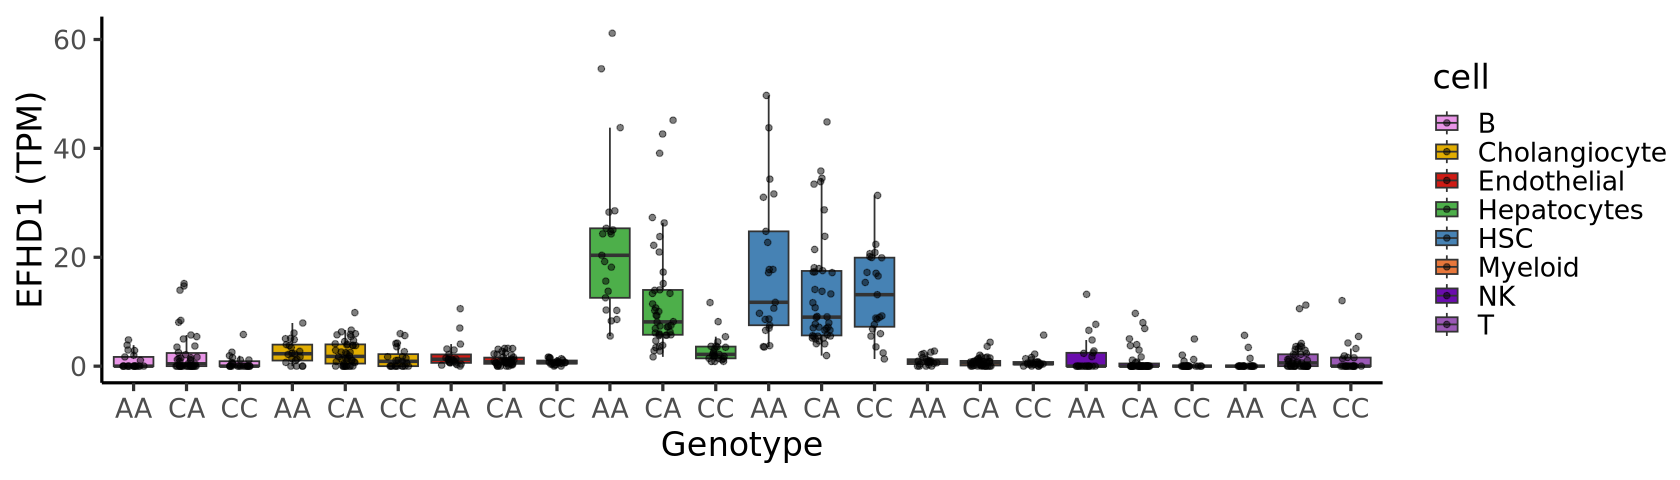

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


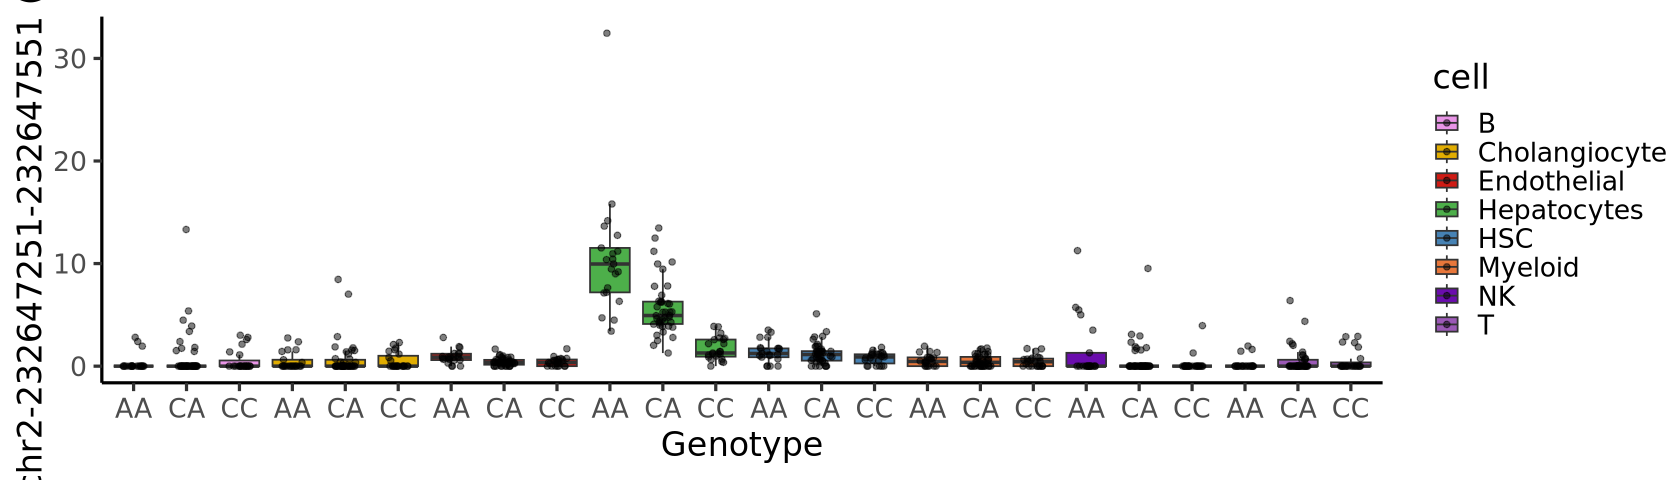

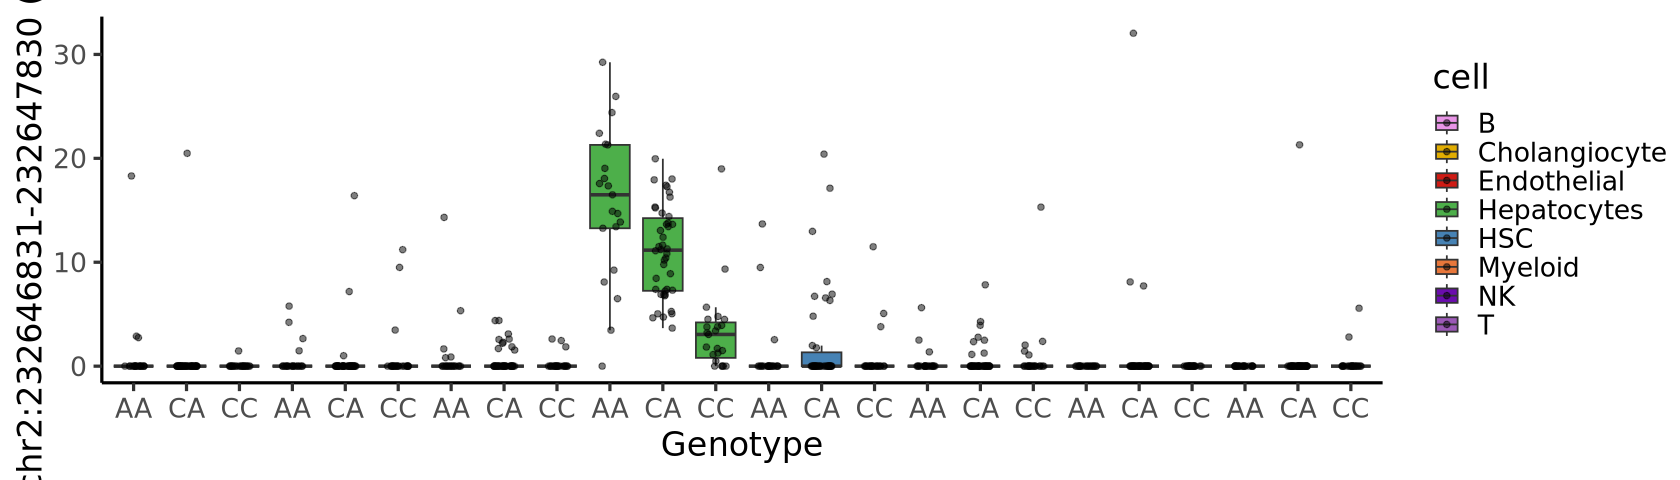

In [25]:
options(repr.plot.width=14, repr.plot.height=4)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
#dev.off()

In [26]:
options(repr.plot.width=14, repr.plot.height=4)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
dev.off()

pdf 
  2

pdf 
  2

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

# Locus Zoom

In [30]:
eqtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == gene)

dim(eqtl.res)
head(eqtl.res)

Rows: 5415703 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (7): start_distance, af, ma_samples, ma_count, pval_nominal, slope, slop...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 3621    9

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
EFHD1,rs6720815,-999932,0.3779070,54,65,0.9329331,-0.01445592,0.1709629
EFHD1,rs1897809,-999073,0.3779070,54,65,0.9329331,-0.01445592,0.1709629
EFHD1,rs80258191,-998742,0.0872093,13,15,0.1219851,0.40917253,0.2603472
EFHD1,rs10175445,-998627,0.4069767,56,70,0.7705016,0.04948442,0.1687640
EFHD1,rs10210477,-998375,0.4069767,56,70,0.7705016,0.04948442,0.1687640
EFHD1,rs4973452,-997723,0.9302325,12,12,0.2057294,0.42318577,0.3303253


In [31]:
eqtl.res$snp.id <- rownames(vcf.df[match(eqtl.res$variant_id, vcf.df$ID),])
eqtl.res$pos <- as.numeric(str_split(eqtl.res$snp.id, ':', simplify=T)[,2])

dim(eqtl.res)
head(eqtl.res)

[1] 3621   11

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
EFHD1,rs6720815,-999932,0.3779070,54,65,0.9329331,-0.01445592,0.1709629,chr2:231606125:T:C,231606125
EFHD1,rs1897809,-999073,0.3779070,54,65,0.9329331,-0.01445592,0.1709629,chr2:231606984:A:G,231606984
EFHD1,rs80258191,-998742,0.0872093,13,15,0.1219851,0.40917253,0.2603472,chr2:231607315:T:A,231607315
EFHD1,rs10175445,-998627,0.4069767,56,70,0.7705016,0.04948442,0.1687640,chr2:231607430:T:C,231607430
EFHD1,rs10210477,-998375,0.4069767,56,70,0.7705016,0.04948442,0.1687640,chr2:231607682:G:A,231607682
EFHD1,rs4973452,-997723,0.9302325,12,12,0.2057294,0.42318577,0.3303253,chr2:231608334:G:A,231608334


In [32]:
ATAC.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == atac.feat)

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

Rows: 173859072 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 3575   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr2-232647251-232647551,rs113500090,-999047,-999346,0.09883721,15,17,0.99034663,-0.003192732,0.2626421
chr2-232647251-232647551,rs11685287,-998539,-998838,0.59302324,54,70,0.07262212,-0.309748300,0.1691065
chr2-232647251-232647551,rs9288673,-997171,-997470,0.92441860,13,13,0.94016765,-0.028109150,0.3727211
chr2-232647251-232647551,rs28430312,-996777,-997076,0.17441860,27,30,0.85122394,0.041297270,0.2191124
chr2-232647251-232647551,rs112863428,-996511,-996810,0.12790698,20,22,0.09935433,0.381913930,0.2276830
chr2-232647251-232647551,rs13015276,-995371,-995670,0.94186044,10,10,0.89775583,-0.051575500,0.3994557


In [33]:
ATAC.qtl.res$snp.id <- rownames(vcf.df[match(ATAC.qtl.res$variant_id, vcf.df$ID),])
ATAC.qtl.res$pos <- as.numeric(str_split(ATAC.qtl.res$snp.id, ':', simplify=T)[,2])

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

[1] 3575   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr2-232647251-232647551,rs113500090,-999047,-999346,0.09883721,15,17,0.99034663,-0.003192732,0.2626421,chr2:231648205:C:T,231648205
chr2-232647251-232647551,rs11685287,-998539,-998838,0.59302324,54,70,0.07262212,-0.309748300,0.1691065,chr2:231648713:A:G,231648713
chr2-232647251-232647551,rs9288673,-997171,-997470,0.92441860,13,13,0.94016765,-0.028109150,0.3727211,chr2:231650081:A:T,231650081
chr2-232647251-232647551,rs28430312,-996777,-997076,0.17441860,27,30,0.85122394,0.041297270,0.2191124,chr2:231650475:T:G,231650475
chr2-232647251-232647551,rs112863428,-996511,-996810,0.12790698,20,22,0.09935433,0.381913930,0.2276830,chr2:231650741:C:T,231650741
chr2-232647251-232647551,rs13015276,-995371,-995670,0.94186044,10,10,0.89775583,-0.051575500,0.3994557,chr2:231651881:A:G,231651881


In [34]:
H3K27ac.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == ac.feat)

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

Rows: 77947148 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 3577   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr2:232646831-232647830,rs9989905,-999595,-1000593,0.29651162,44,51,0.4670899,0.12540042,0.1711948
chr2:232646831-232647830,rs113500090,-998627,-999625,0.09883721,15,17,0.8231266,-0.05552128,0.2471616
chr2:232646831-232647830,rs11685287,-998119,-999117,0.59302324,54,70,0.8375095,-0.03329152,0.1615380
chr2:232646831-232647830,rs9288673,-996751,-997749,0.92441860,13,13,0.9724009,-0.01338713,0.3851197
chr2:232646831-232647830,rs28430312,-996357,-997355,0.17441860,27,30,0.3878329,-0.18821639,0.2161613
chr2:232646831-232647830,rs112863428,-996091,-997089,0.12790698,20,22,0.4931488,0.16596451,0.2404971


In [35]:
H3K27ac.qtl.res$snp.id <- rownames(vcf.df[match(H3K27ac.qtl.res$variant_id, vcf.df$ID),])
H3K27ac.qtl.res$pos <- as.numeric(str_split(H3K27ac.qtl.res$snp.id, ':', simplify=T)[,2])

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

[1] 3577   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr2:232646831-232647830,rs9989905,-999595,-1000593,0.29651162,44,51,0.4670899,0.12540042,0.1711948,chr2:231647237:G:A,231647237
chr2:232646831-232647830,rs113500090,-998627,-999625,0.09883721,15,17,0.8231266,-0.05552128,0.2471616,chr2:231648205:C:T,231648205
chr2:232646831-232647830,rs11685287,-998119,-999117,0.59302324,54,70,0.8375095,-0.03329152,0.1615380,chr2:231648713:A:G,231648713
chr2:232646831-232647830,rs9288673,-996751,-997749,0.92441860,13,13,0.9724009,-0.01338713,0.3851197,chr2:231650081:A:T,231650081
chr2:232646831-232647830,rs28430312,-996357,-997355,0.17441860,27,30,0.3878329,-0.18821639,0.2161613,chr2:231650475:T:G,231650475
chr2:232646831-232647830,rs112863428,-996091,-997089,0.12790698,20,22,0.4931488,0.16596451,0.2404971,chr2:231650741:C:T,231650741


In [ ]:
atac.feat <- 'chr2-232647251-232647551'
ac.feat <- 'chr2:232646831-232647830'
variant <- 'rs7604422'
variant.pos <- 232645051

In [37]:
region <- c(232600000,232700000)
region[2]-region[1]

[1] 1e+05

pdf 
  2

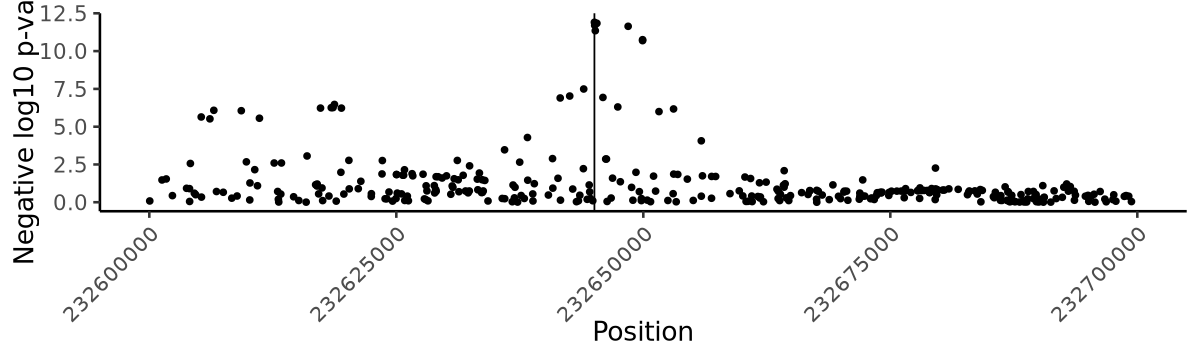

In [38]:
#chr12-52884847-52885147
options(repr.plot.width=10, repr.plot.height=3)
p1 <- ggplot(filter(ALT, chr.hg38 == chr & pos.hg38 > region[1] & pos.hg38 < region[2]), 
      aes(x=pos.hg38, y=-log10(P))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_GWAS_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 3445 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3445 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

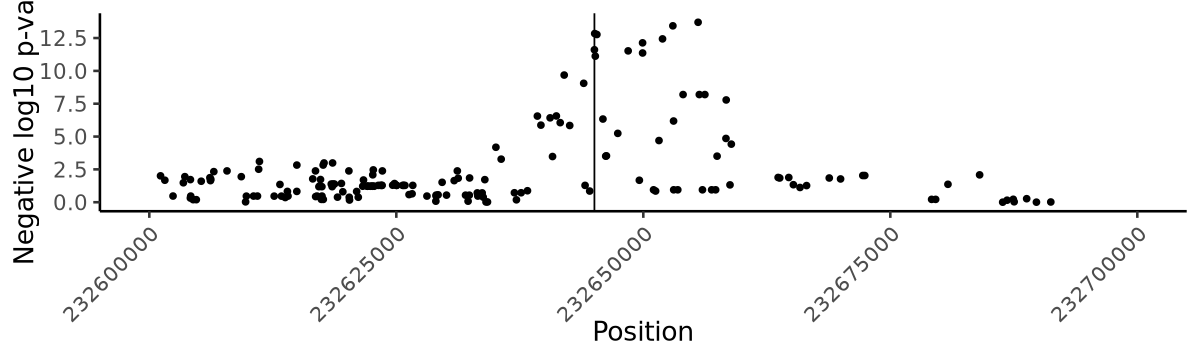

In [39]:
p1 <- ggplot(eqtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))
p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_eQTL_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 3399 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3399 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

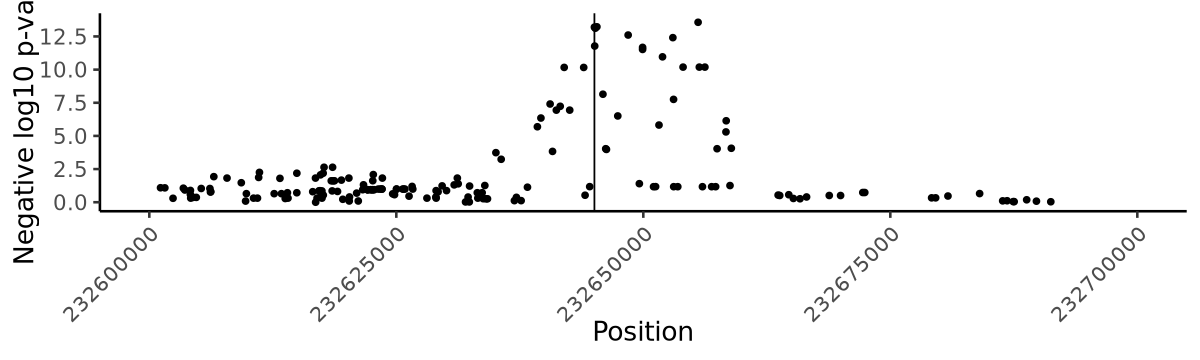

In [40]:
p1 <- ggplot(ATAC.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_caQTL_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 3401 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3401 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

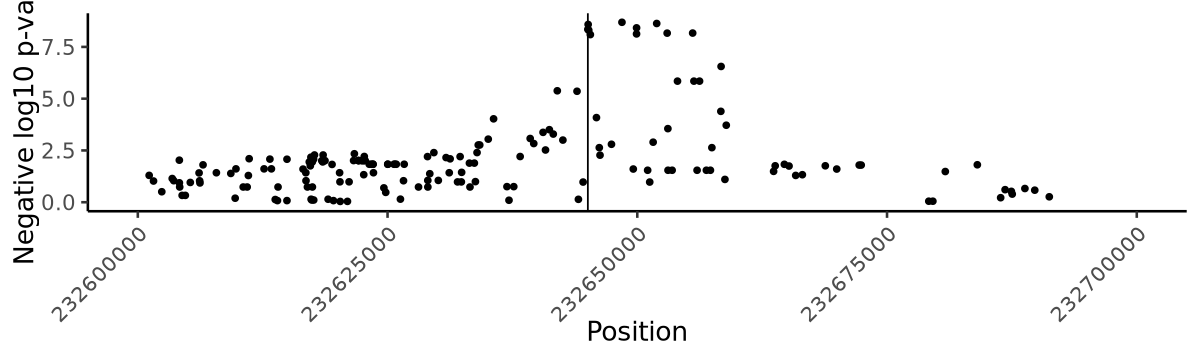

In [41]:
p1 <- ggplot(H3K27ac.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_H3K27acQTL_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


pdf 
  2

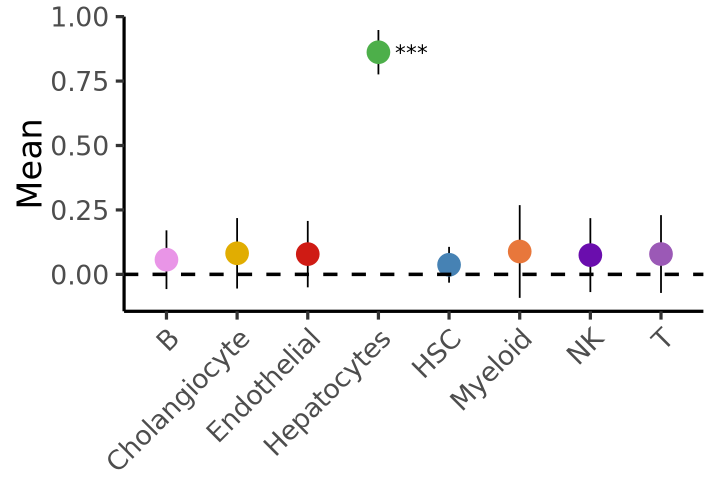

In [5]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(eQTL.post.mean[str_detect(rownames(eQTL.post.mean), 'EFHD1'),]), 
          sd=unlist(eQTL.post.sd[str_detect(rownames(eQTL.post.sd), 'EFHD1'),]),
          ct=colnames(eQTL.post.mean),
          lfsr=unlist(eQTL.post.lfsr[str_detect(rownames(eQTL.post.lfsr), 'EFHD1'),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_eQTL_',gene,'.pdf'), width=6, height=4)
p1
dev.off()

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


pdf 
  2

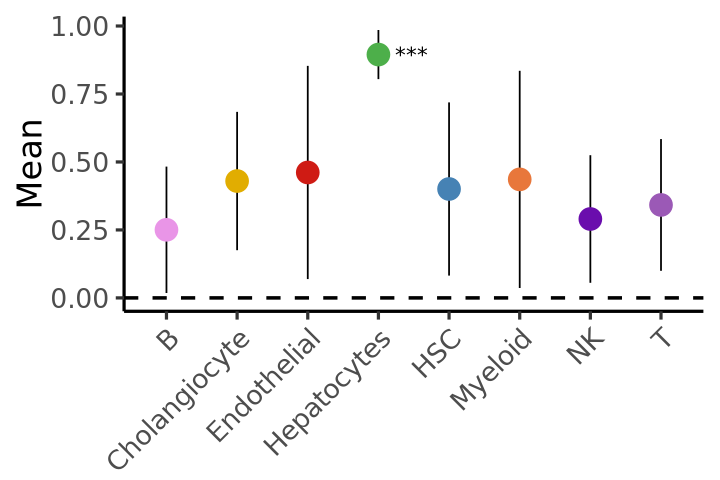

In [42]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(caQTL.post.mean[str_detect(rownames(caQTL.post.mean), atac.feat),]), 
          sd=unlist(caQTL.post.sd[str_detect(rownames(caQTL.post.sd), atac.feat),]),
          ct=colnames(caQTL.post.mean),
          lfsr=unlist(caQTL.post.lfsr[str_detect(rownames(caQTL.post.lfsr), atac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_caQTL_',gene,'.pdf'), width=6, height=4)
p1
dev.off()

pdf 
  2

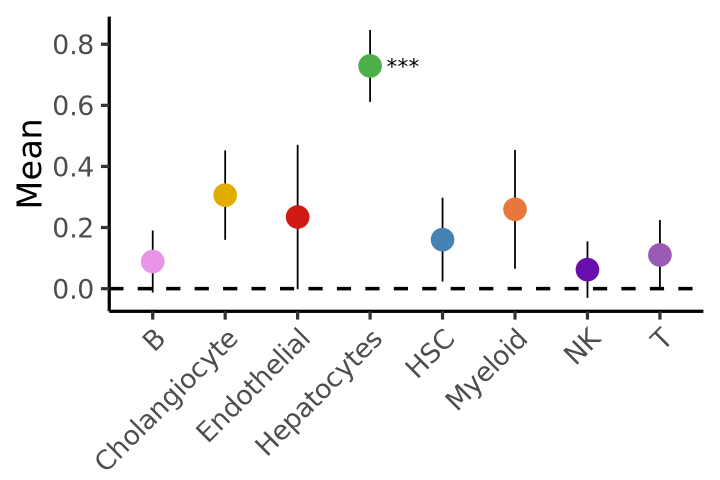

In [43]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(H3K27acQTL.post.mean[str_detect(rownames(H3K27acQTL.post.mean), ac.feat),]), 
          sd=unlist(H3K27acQTL.post.sd[str_detect(rownames(H3K27acQTL.post.sd), ac.feat),]),
          ct=colnames(H3K27acQTL.post.mean),
          lfsr=unlist(H3K27acQTL.post.lfsr[str_detect(rownames(H3K27acQTL.post.lfsr), ac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip()

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_H3K27acQTL_',gene,'_flipped.pdf'), width=6, height=4)
p1
dev.off()

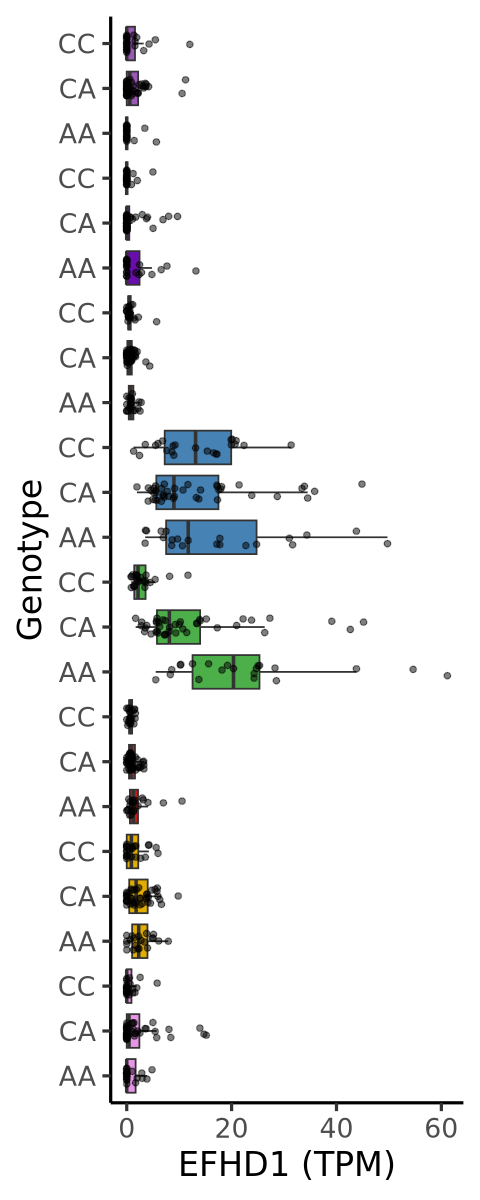

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


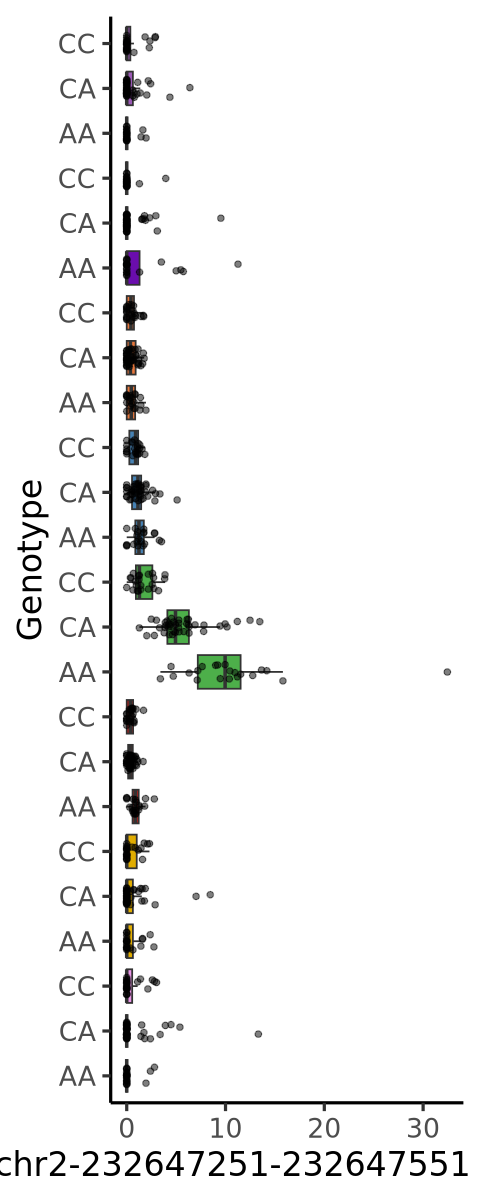

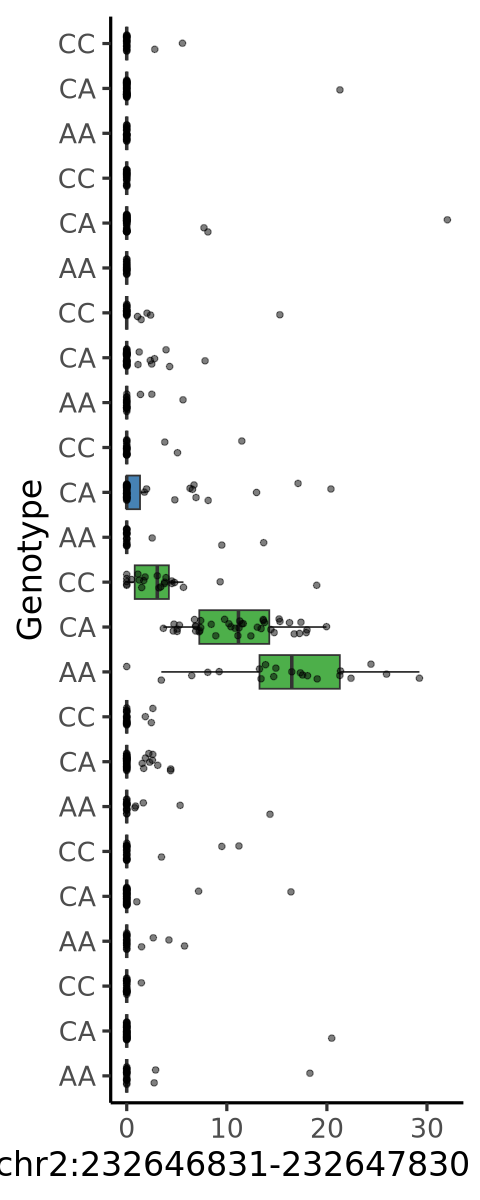

In [44]:
options(repr.plot.width=4, repr.plot.height=10)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
#dev.off()

In [45]:
options(repr.plot.width=4, repr.plot.height=10)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
dev.off()

pdf 
  2

pdf 
  2

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

In [32]:
filter(fine.mapping, Chr==19 & LEAD.SNP=='rs4805033')

CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,chr.hg38,end.hg38,start.hg38
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>
,rs4805033,rs7248901,19,33845443,T,C,0.439,-0.036,0.0064,3.11e-08,218595,30.39%,CEBPA;CEBPG,CEBPA;CEBPG,19,33354537,33354536
,rs4805033,rs4805033,19,33839554,G,A,0.439,-0.037,0.0066,3.06e-08,218595,26.11%,CEBPA;CEBPG,CEBPA;CEBPG,19,33348648,33348647
,rs4805033,rs1423063,19,33846635,C,T,0.439,-0.036,0.0064,3.46e-08,218595,25.55%,CEBPA;CEBPG,CEBPA;CEBPG,19,33355729,33355728
,rs4805033,rs10401477,19,33920721,A,C,0.417,0.035,0.0067,2.50e-07,218595,3.19%,CEBPA;CEBPG,CEBPA;CEBPG,19,33429815,33429814
,rs4805033,rs10407802,19,33921263,A,C,0.417,0.035,0.0067,2.48e-07,218595,3.19%,CEBPA;CEBPG,CEBPA;CEBPG,19,33430357,33430356
,rs4805033,rs1423062,19,33846522,G,A,0.411,-0.033,0.0065,4.82e-07,218595,1.45%,CEBPA;CEBPG,CEBPA;CEBPG,19,33355616,33355615
,rs4805033,rs6510382,19,33918569,T,G,0.349,0.034,0.0069,6.54e-07,218595,1.24%,CEBPA;CEBPG,CEBPA;CEBPG,19,33427663,33427662
,rs4805033,rs10417411,19,33919486,G,C,0.349,0.034,0.0069,6.84e-07,218595,1.24%,CEBPA;CEBPG,CEBPA;CEBPG,19,33428580,33428579
,rs4805033,rs143810801,19,34086951,T,C,0.007,0.281,0.0600,2.88e-06,216679,1.14%,CEBPA;CEBPG,CEBPA;CEBPG,19,33596045,33596044


# CEBPA

In [99]:
gene <- 'CEBPA'
atac.feat <- 'chr19-33508975-33509275'
ac.feat <- 'chr19:33508664-33509663'
variant <- 'rs7248901'
variant.pos <- 33354536
chr <- 19
#chr19-4327651-4327951

In [100]:
#chr19:33,299,934-33,302,534
#Also some loci look potentially interesting from the loops - e.g. PEPD has many interactions with CEBPA

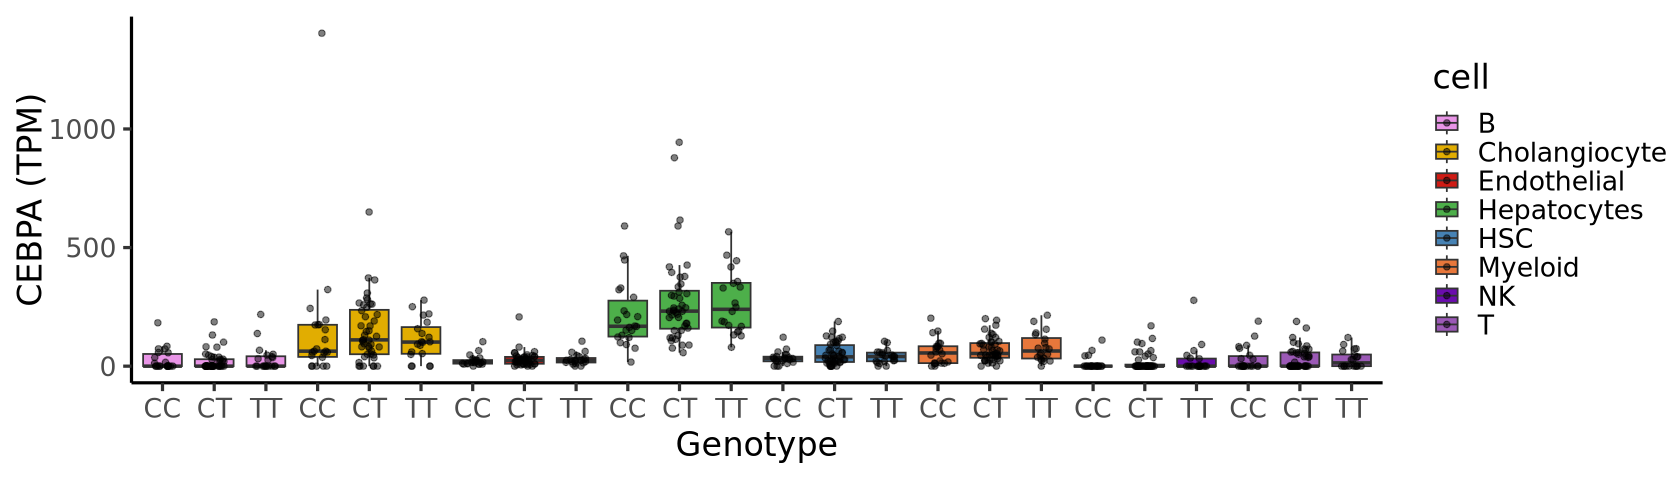

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


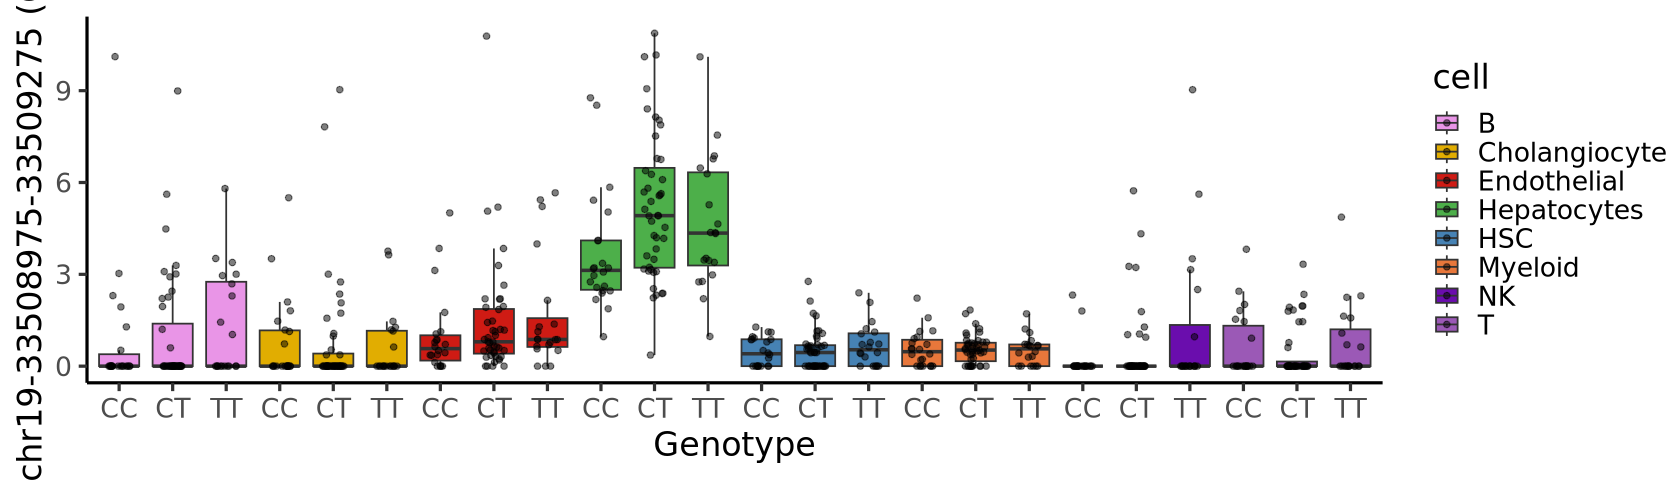

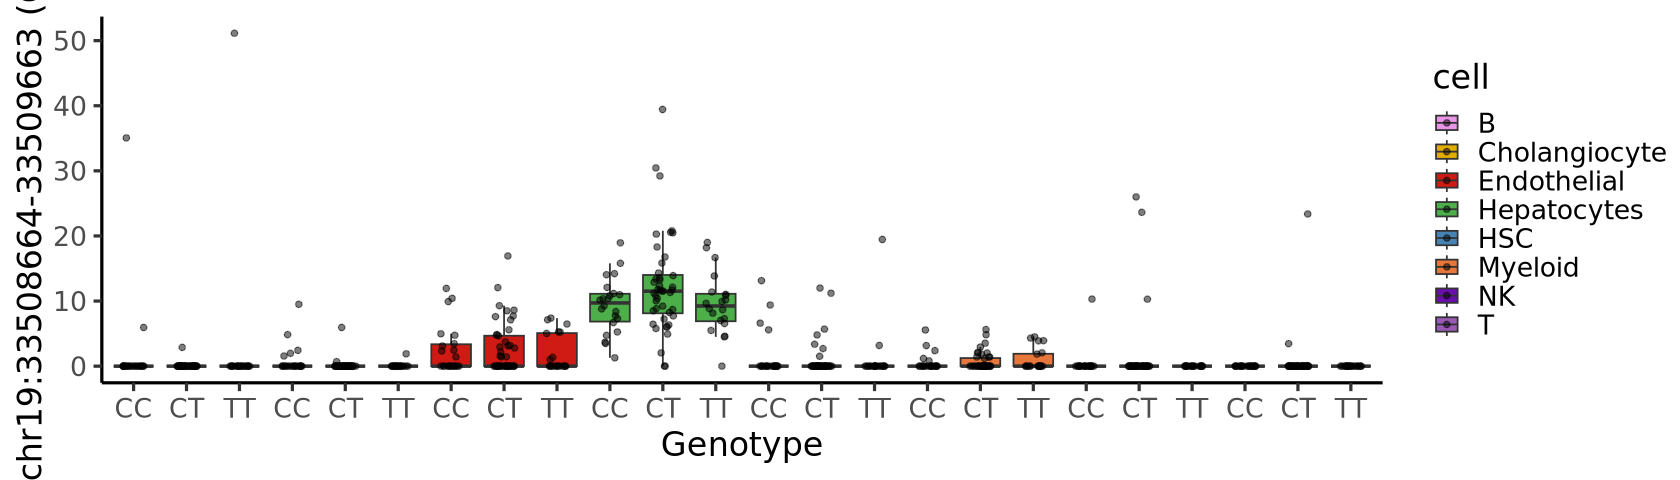

In [101]:
options(repr.plot.width=14, repr.plot.height=4)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
#dev.off()

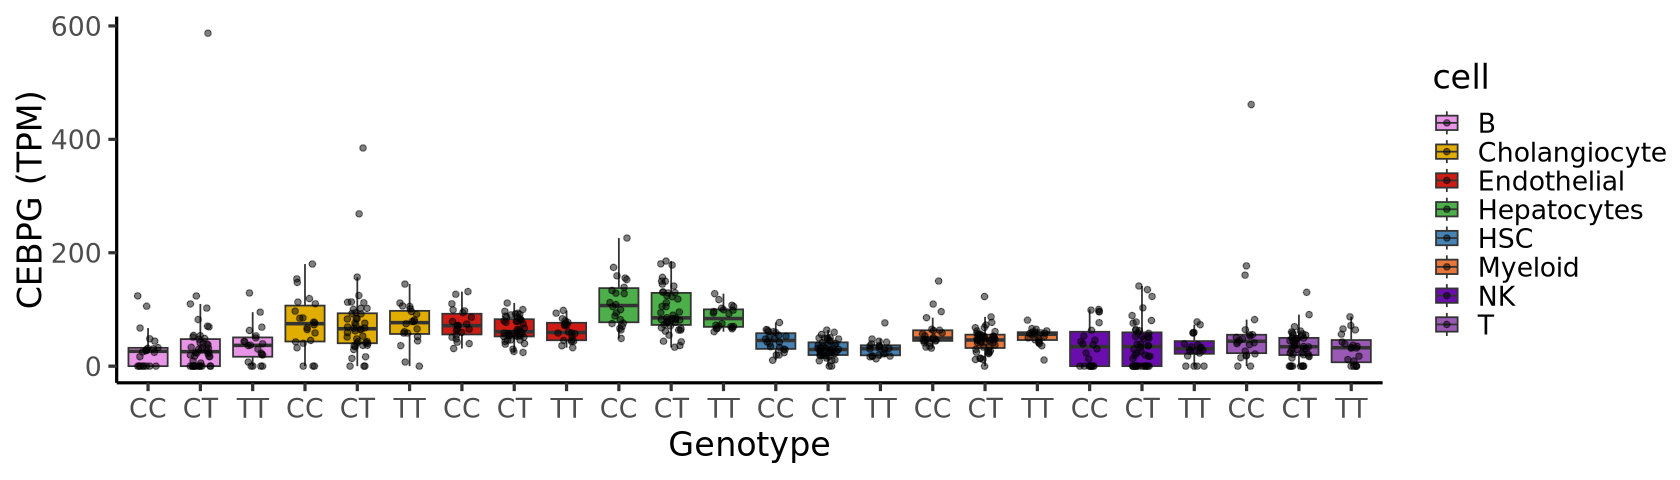

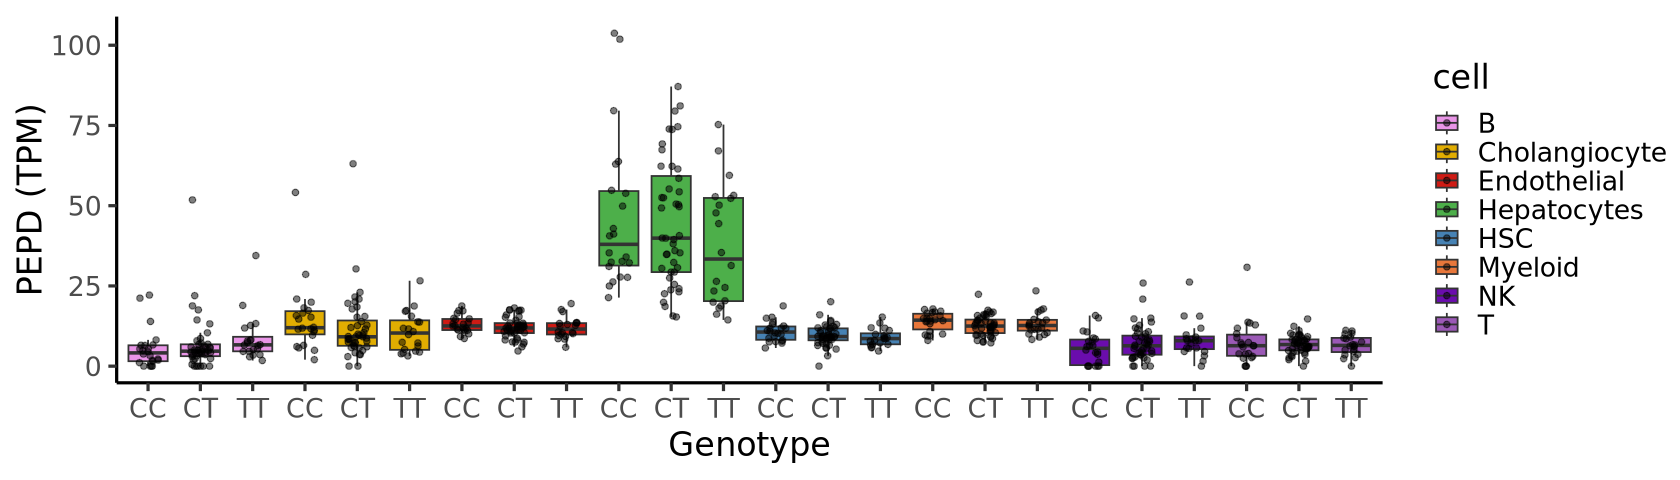

In [102]:
qtl.boxplot('CEBPG',variant, vcf.df, TPM, celltype_colors, 'TPM')
qtl.boxplot('PEPD',variant, vcf.df, TPM, celltype_colors, 'TPM')

In [103]:
options(repr.plot.width=14, repr.plot.height=4)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
dev.off()

pdf 
  2

pdf 
  2

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

In [104]:
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_PEPD_eQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot('PEPD',variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_CEBPG_eQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot('CEBPG',variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()

pdf 
  2

pdf 
  2

# Locus Zoom

In [105]:
eqtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == gene)

dim(eqtl.res)
head(eqtl.res)

Rows: 4672898 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (7): start_distance, af, ma_samples, ma_count, pval_nominal, slope, slop...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4675    9

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CEBPA,rs66700412,-999447,0.1976744,30,34,0.37159881,0.15582748,0.1729256
CEBPA,rs12608785,-997126,0.1686047,26,29,0.37376014,0.17483234,0.1949016
CEBPA,rs2078491,-997057,0.2500000,38,43,0.05558801,0.29337510,0.1498878
CEBPA,rs73030391,-996033,0.3255814,47,56,0.79888959,-0.04233069,0.1653103
CEBPA,rs8103676,-994502,0.2500000,38,43,0.05558801,0.29337510,0.1498878
CEBPA,rs10417813,-991363,0.4767442,61,82,0.40607159,0.11729562,0.1400542


In [106]:
eqtl.res$snp.id <- rownames(vcf.df[match(eqtl.res$variant_id, vcf.df$ID),])
eqtl.res$pos <- as.numeric(str_split(eqtl.res$snp.id, ':', simplify=T)[,2])

dim(eqtl.res)
head(eqtl.res)

[1] 4675   11

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
CEBPA,rs66700412,-999447,0.1976744,30,34,0.37159881,0.15582748,0.1729256,chr19:32303087:C:G,32303087
CEBPA,rs12608785,-997126,0.1686047,26,29,0.37376014,0.17483234,0.1949016,chr19:32305408:A:G,32305408
CEBPA,rs2078491,-997057,0.2500000,38,43,0.05558801,0.29337510,0.1498878,chr19:32305477:A:G,32305477
CEBPA,rs73030391,-996033,0.3255814,47,56,0.79888959,-0.04233069,0.1653103,chr19:32306501:T:C,32306501
CEBPA,rs8103676,-994502,0.2500000,38,43,0.05558801,0.29337510,0.1498878,chr19:32308032:T:C,32308032
CEBPA,rs10417813,-991363,0.4767442,61,82,0.40607159,0.11729562,0.1400542,chr19:32311171:T:G,32311171


In [107]:
ATAC.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == atac.feat)

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

Rows: 57055094 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4614   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr19-33508975-33509275,rs35305910,-999990,-1000289,0.11627907,18,20,0.4408575,-0.19106181,0.2460291
chr19-33508975-33509275,rs73038243,-999330,-999629,0.09302325,14,16,0.5502277,-0.17488720,0.2908662
chr19-33508975-33509275,rs10048434,-999106,-999405,0.20348836,34,35,0.6906168,-0.09537739,0.2383236
chr19-33508975-33509275,rs7251458,-998439,-998738,0.24418604,40,42,0.4645111,-0.16196914,0.2198367
chr19-33508975-33509275,rs6510250,-998136,-998435,0.20348836,34,35,0.6906168,-0.09537739,0.2383236
chr19-33508975-33509275,rs2159260,-997636,-997935,0.21511628,35,37,0.8264770,-0.04946418,0.2245220


In [108]:
ATAC.qtl.res$snp.id <- rownames(vcf.df[match(ATAC.qtl.res$variant_id, vcf.df$ID),])
ATAC.qtl.res$pos <- as.numeric(str_split(ATAC.qtl.res$snp.id, ':', simplify=T)[,2])

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

[1] 4614   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr19-33508975-33509275,rs35305910,-999990,-1000289,0.11627907,18,20,0.4408575,-0.19106181,0.2460291,chr19:32508986:C:T,32508986
chr19-33508975-33509275,rs73038243,-999330,-999629,0.09302325,14,16,0.5502277,-0.17488720,0.2908662,chr19:32509646:C:T,32509646
chr19-33508975-33509275,rs10048434,-999106,-999405,0.20348836,34,35,0.6906168,-0.09537739,0.2383236,chr19:32509870:G:A,32509870
chr19-33508975-33509275,rs7251458,-998439,-998738,0.24418604,40,42,0.4645111,-0.16196914,0.2198367,chr19:32510537:G:C,32510537
chr19-33508975-33509275,rs6510250,-998136,-998435,0.20348836,34,35,0.6906168,-0.09537739,0.2383236,chr19:32510840:A:C,32510840
chr19-33508975-33509275,rs2159260,-997636,-997935,0.21511628,35,37,0.8264770,-0.04946418,0.2245220,chr19:32511340:G:C,32511340


In [109]:
H3K27ac.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == ac.feat)

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

Rows: 37766063 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4615   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr19:33508664-33509663,rs73038242,-999837,-1000835,0.06395349,10,11,0.79078027,-0.08460789,0.3173101
chr19:33508664-33509663,rs35305910,-999679,-1000677,0.11627907,18,20,0.06723083,0.46976674,0.2514204
chr19:33508664-33509663,rs73038243,-999019,-1000017,0.09302325,14,16,0.78477194,-0.07188222,0.2618715
chr19:33508664-33509663,rs10048434,-998795,-999793,0.20348836,34,35,0.47753660,-0.19418310,0.2714545
chr19:33508664-33509663,rs7251458,-998128,-999126,0.24418604,40,42,0.53345667,-0.14593036,0.2328041
chr19:33508664-33509663,rs6510250,-997825,-998823,0.20348836,34,35,0.47753660,-0.19418310,0.2714545


In [110]:
H3K27ac.qtl.res$snp.id <- rownames(vcf.df[match(H3K27ac.qtl.res$variant_id, vcf.df$ID),])
H3K27ac.qtl.res$pos <- as.numeric(str_split(H3K27ac.qtl.res$snp.id, ':', simplify=T)[,2])

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

[1] 4615   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr19:33508664-33509663,rs73038242,-999837,-1000835,0.06395349,10,11,0.79078027,-0.08460789,0.3173101,chr19:32508828:T:C,32508828
chr19:33508664-33509663,rs35305910,-999679,-1000677,0.11627907,18,20,0.06723083,0.46976674,0.2514204,chr19:32508986:C:T,32508986
chr19:33508664-33509663,rs73038243,-999019,-1000017,0.09302325,14,16,0.78477194,-0.07188222,0.2618715,chr19:32509646:C:T,32509646
chr19:33508664-33509663,rs10048434,-998795,-999793,0.20348836,34,35,0.47753660,-0.19418310,0.2714545,chr19:32509870:G:A,32509870
chr19:33508664-33509663,rs7251458,-998128,-999126,0.24418604,40,42,0.53345667,-0.14593036,0.2328041,chr19:32510537:G:C,32510537
chr19:33508664-33509663,rs6510250,-997825,-998823,0.20348836,34,35,0.47753660,-0.19418310,0.2714545,chr19:32510840:A:C,32510840


In [113]:
region <- c(33225000,33575000)
region[2]-region[1]
#chr19:33225000-33575000

[1] 350000

pdf 
  2

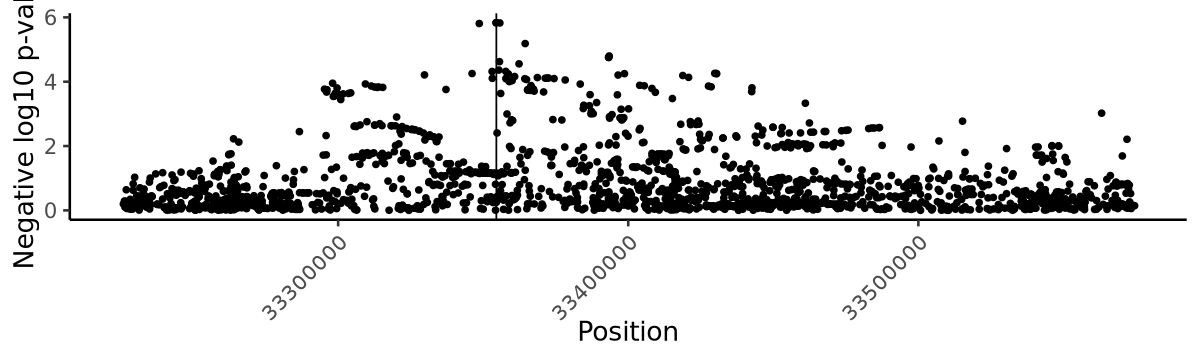

In [114]:
#chr12-52884847-52885147
options(repr.plot.width=10, repr.plot.height=3)
p1 <- ggplot(filter(ALT, chr.hg38 == chr & pos.hg38 > region[1] & pos.hg38 < region[2]), 
      aes(x=pos.hg38, y=-log10(P))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_GWAS_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 3734 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3734 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

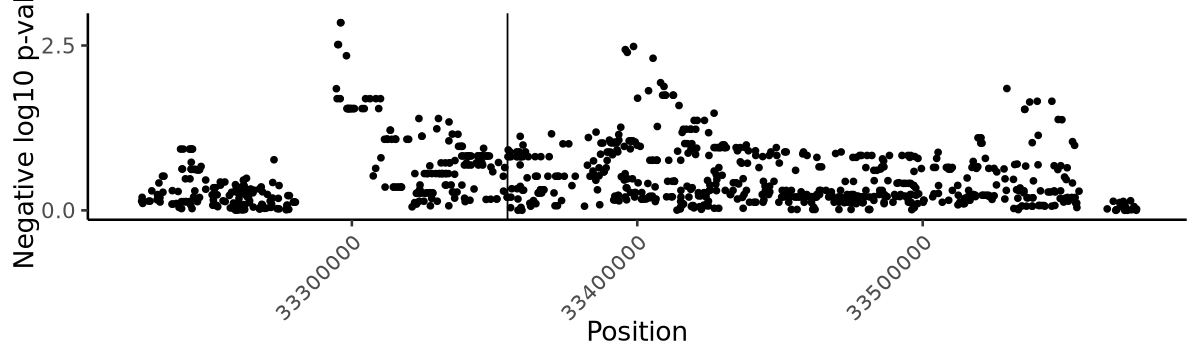

In [115]:
p1 <- ggplot(eqtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))
p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_eQTL_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 3673 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3673 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

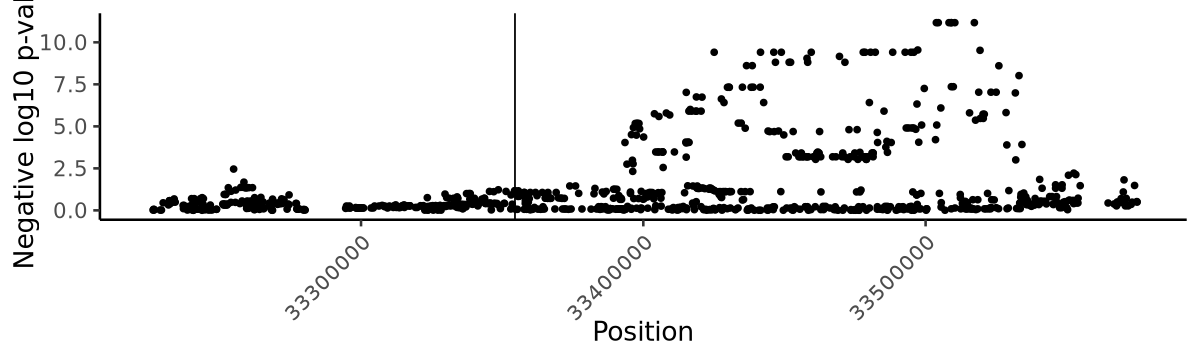

In [116]:
p1 <- ggplot(ATAC.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_caQTL_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 3674 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 3674 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

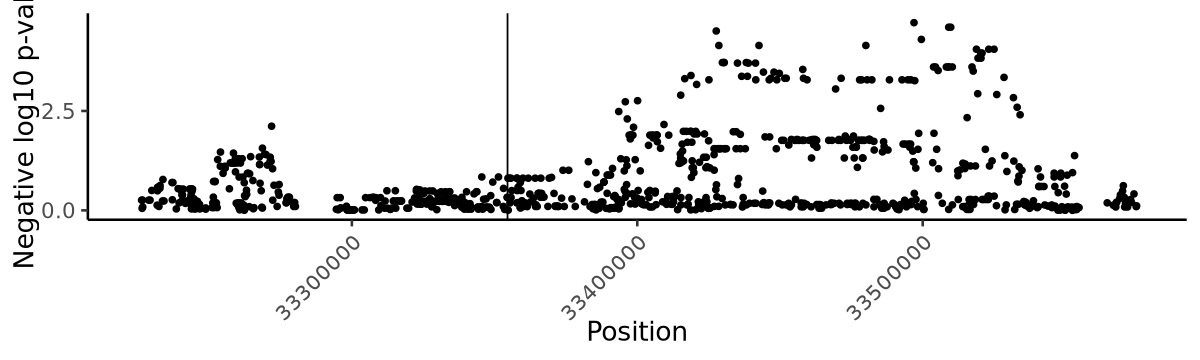

In [117]:
p1 <- ggplot(H3K27ac.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_H3K27acQTL_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

In [50]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(eQTL.post.mean[str_detect(rownames(eQTL.post.mean), gene),]), 
          sd=unlist(eQTL.post.sd[str_detect(rownames(eQTL.post.sd), gene),]),
          ct=colnames(eQTL.post.mean),
          lfsr=unlist(eQTL.post.lfsr[str_detect(rownames(eQTL.post.lfsr), gene),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_eQTL_',gene,'.pdf'), width=6, height=4)
p1
dev.off()

ERROR: Error in data.frame(mean = unlist(eQTL.post.mean[str_detect(rownames(eQTL.post.mean), : arguments imply differing number of rows: 0, 8


pdf 
  2

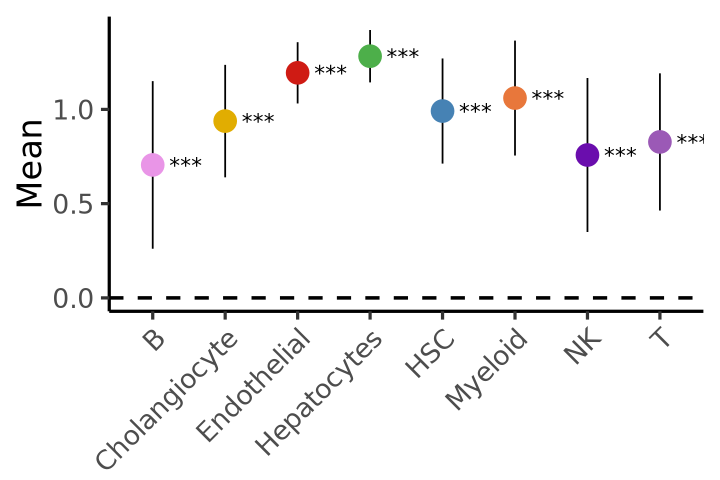

In [118]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(caQTL.post.mean[str_detect(rownames(caQTL.post.mean), atac.feat),]), 
          sd=unlist(caQTL.post.sd[str_detect(rownames(caQTL.post.sd), atac.feat),]),
          ct=colnames(caQTL.post.mean),
          lfsr=unlist(caQTL.post.lfsr[str_detect(rownames(caQTL.post.lfsr), atac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_caQTL_',gene,'.pdf'), width=6, height=4)
p1
dev.off()

In [53]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(H3K27acQTL.post.mean[str_detect(rownames(H3K27acQTL.post.mean), ac.feat),]), 
          sd=unlist(H3K27acQTL.post.sd[str_detect(rownames(H3K27acQTL.post.sd), ac.feat),]),
          ct=colnames(H3K27acQTL.post.mean),
          lfsr=unlist(H3K27acQTL.post.lfsr[str_detect(rownames(H3K27acQTL.post.lfsr), ac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip()

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_H3K27acQTL_',gene,'_flipped.pdf'), width=6, height=4)
p1
dev.off()

ERROR: Error in data.frame(mean = unlist(H3K27acQTL.post.mean[str_detect(rownames(H3K27acQTL.post.mean), : arguments imply differing number of rows: 0, 8


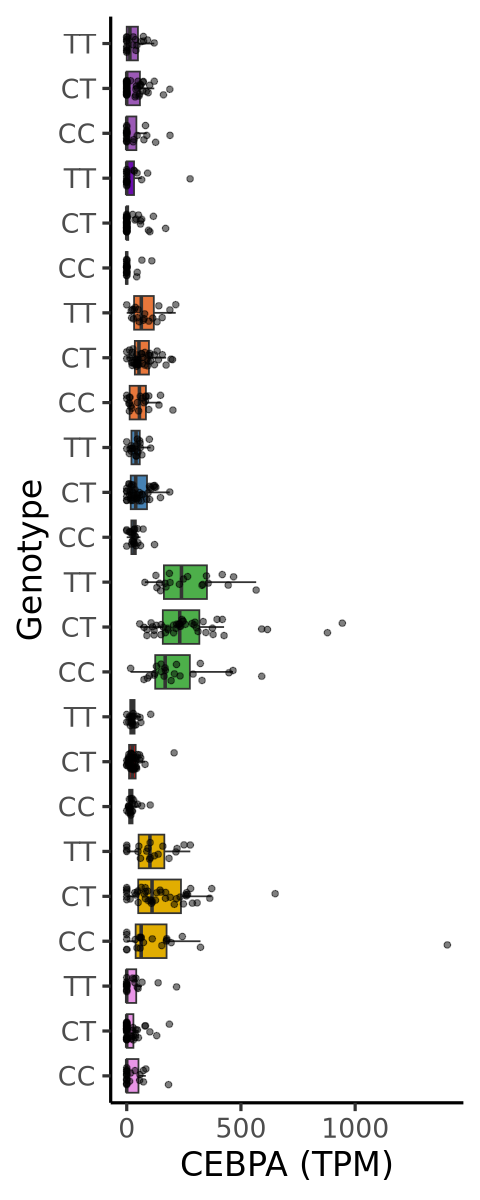

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


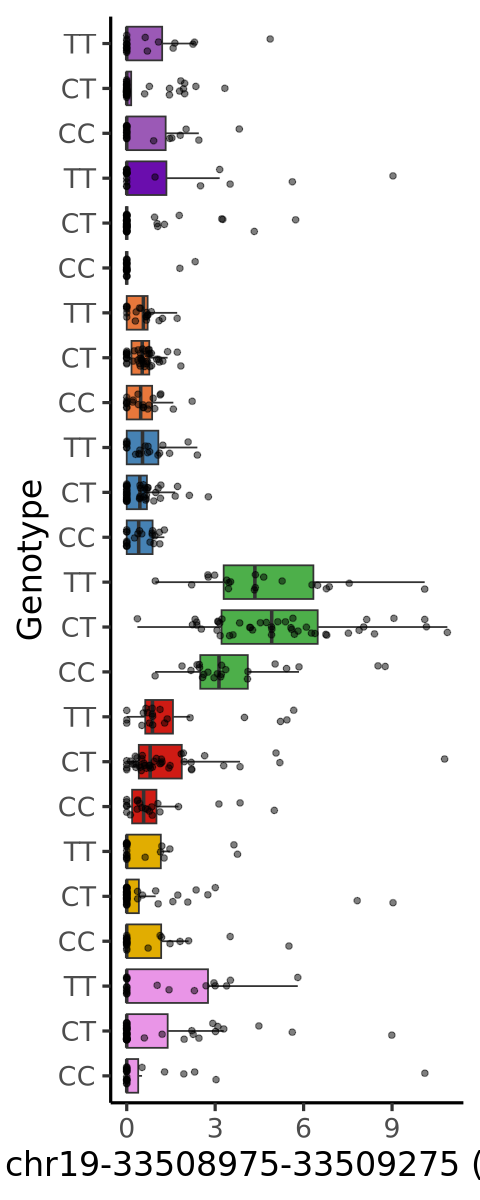

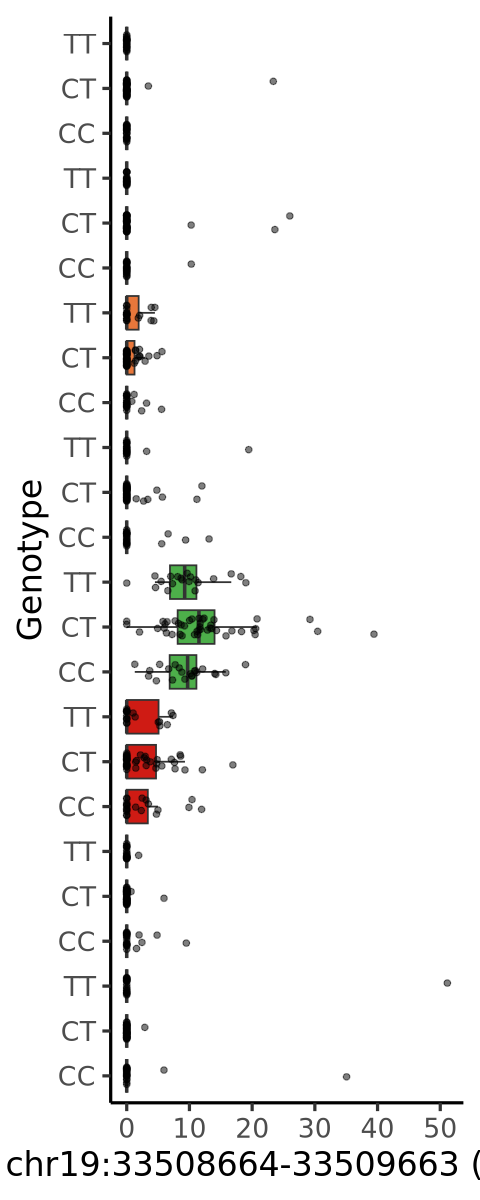

In [54]:
options(repr.plot.width=4, repr.plot.height=10)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
#dev.off()

In [55]:
options(repr.plot.width=4, repr.plot.height=10)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
dev.off()

pdf 
  2

pdf 
  2

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

In [56]:
filter(fine.mapping, Chr=='22')

CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,chr.hg38,end.hg38,start.hg38
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>
,rs738408,rs738408,22,44324730,T,C,0.239,0.267,0.0076,3.99e-273,218595,100.00%,PNPLA3,PNPLA3,22,43928850,43928849
,rs132665,rs132665,22,36564170,G,A,0.145,-0.066,0.0098,1.18e-11,218595,50.41%,APOL3,APOL3,22,36168122,36168121
,rs132665,rs105161,22,36530428,G,A,0.146,-0.065,0.0098,4.37e-11,218595,15.84%,APOL3,APOL3,22,36134380,36134379
,rs132665,rs80576,22,36539804,A,G,0.153,-0.061,0.0094,8.91e-11,218595,7.83%,APOL3,APOL3,22,36143756,36143755
,rs132665,rs132648,22,36552402,T,C,0.156,-0.060,0.0093,1.10e-10,218595,6.52%,APOL3,APOL3,22,36156354,36156353
,rs132665,rs132631,22,36542194,A,C,0.153,-0.061,0.0094,1.12e-10,218595,6.37%,APOL3,APOL3,22,36146146,36146145
,rs132665,rs132646,22,36550067,T,C,0.155,-0.060,0.0093,1.44e-10,218595,4.94%,APOL3,APOL3,22,36154019,36154018
,rs132665,rs132641,22,36544729,A,G,0.153,-0.060,0.0094,1.44e-10,218595,4.85%,APOL3,APOL3,22,36148681,36148680
,rs1547014,rs1547014,22,29100711,T,C,0.342,-0.064,0.0067,1.57e-21,218595,53.50%,CHEK2,CHEK2,22,28704723,28704722


# XBP1

In [ ]:
#XBP1 - chr22-28712079-28712379

In [81]:
gene <- 'XBP1'
atac.feat <- 'chr22-28712079-28712379'
ac.feat <- 'chr22:28711782-28712781'
variant <- 'rs1547014'
variant.pos <- 28704723
chr <- 22

In [82]:
#chr22:28,794,555-28,800,597
#XBP1 - chr22-28712079-28712379

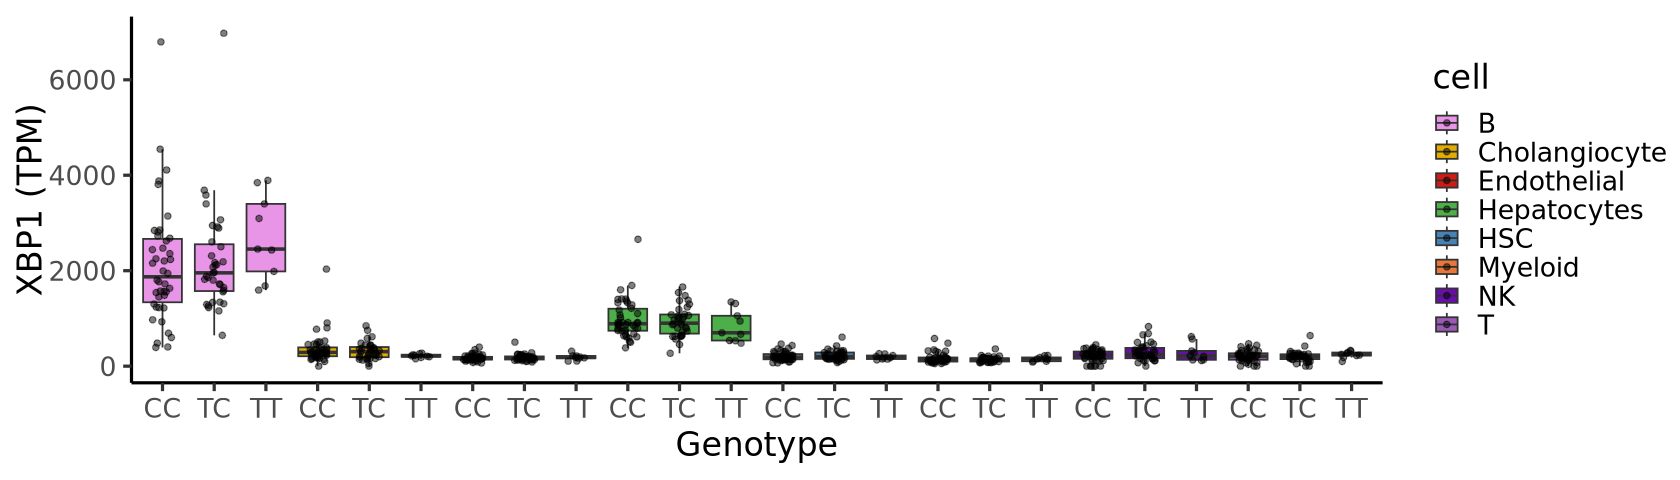

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


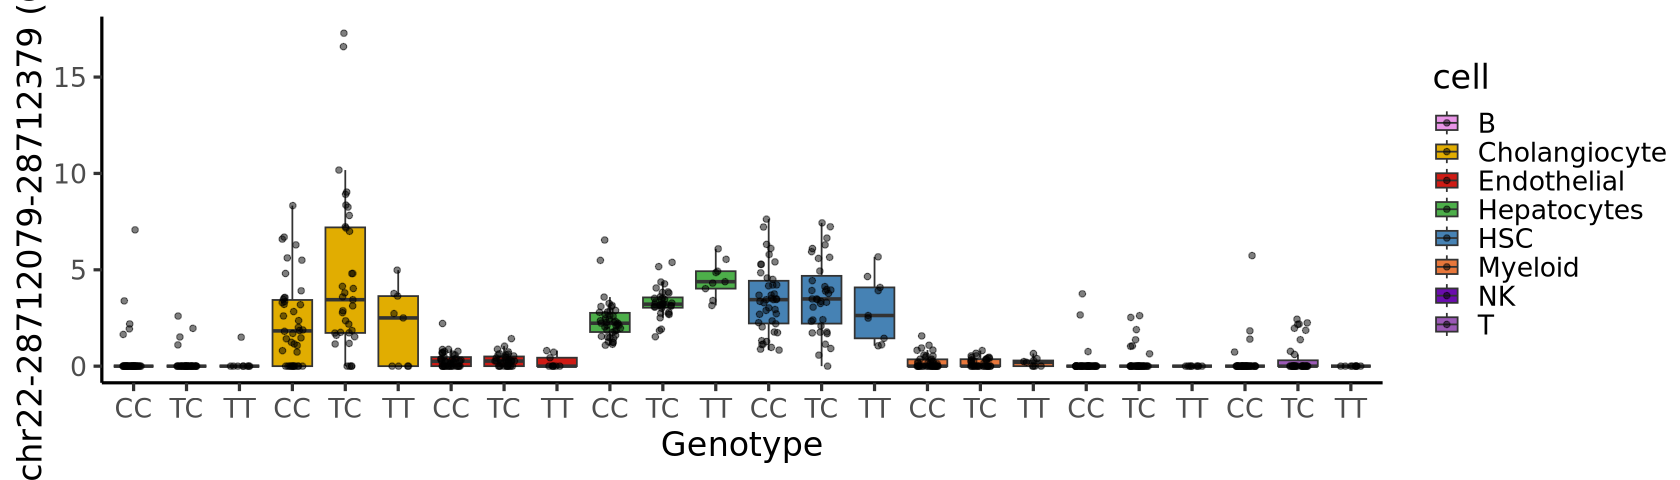

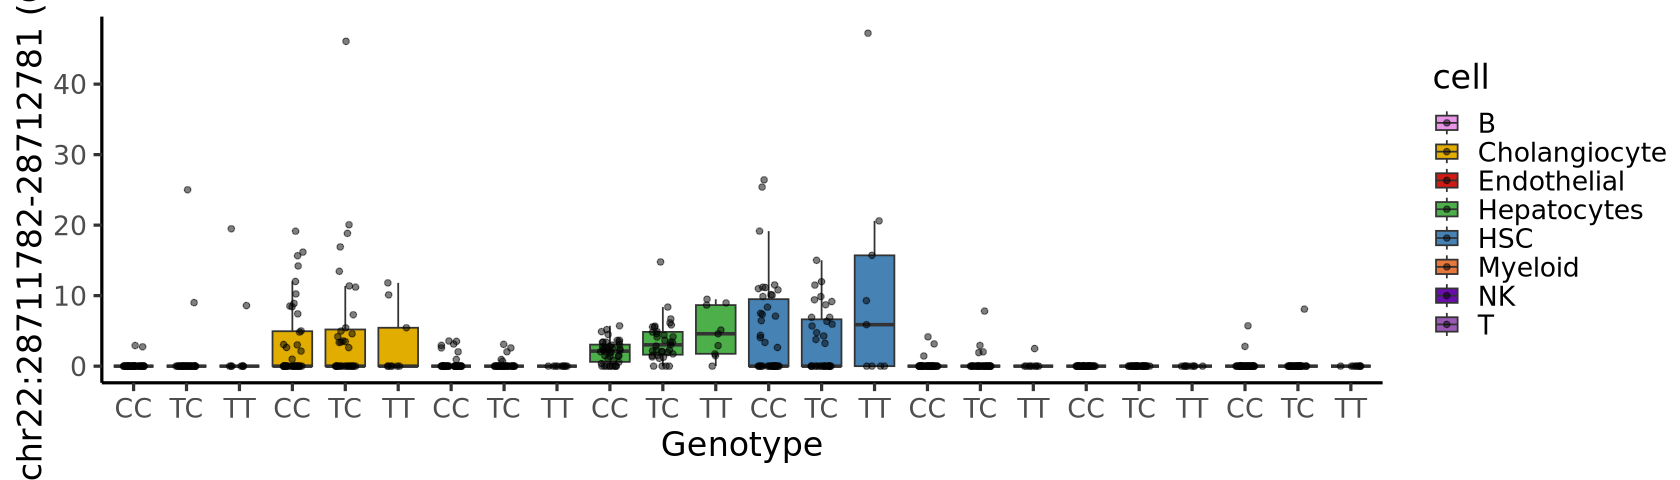

In [83]:
options(repr.plot.width=14, repr.plot.height=4)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
#    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
#dev.off()

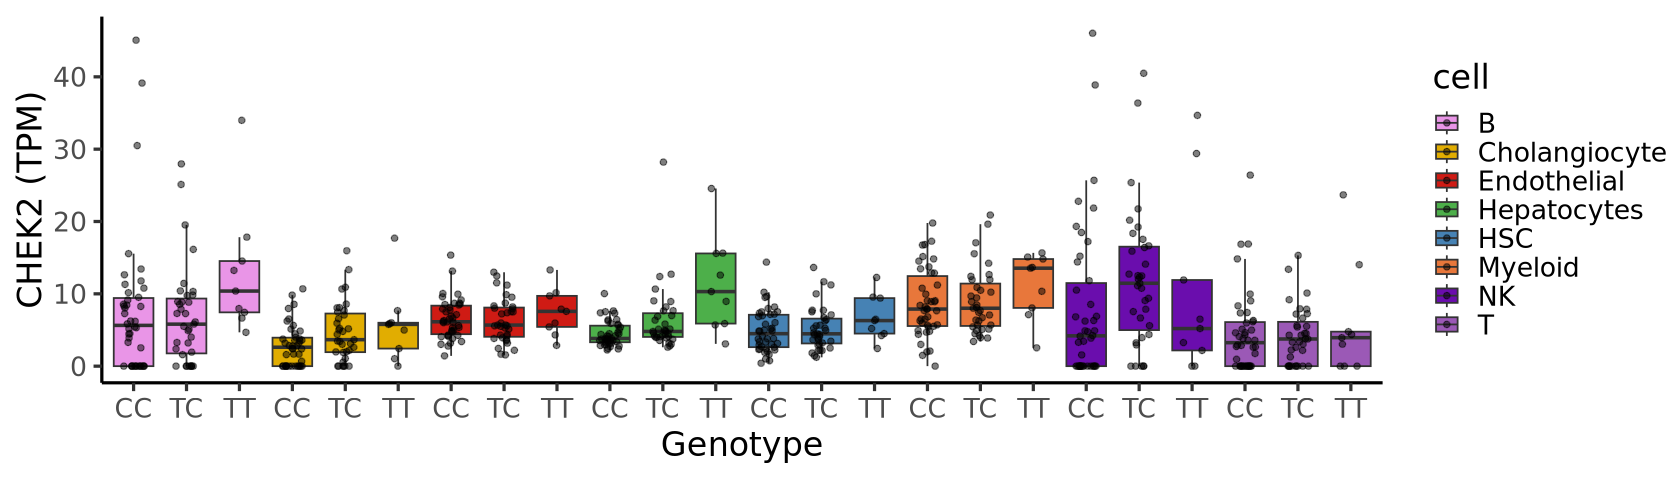

In [84]:
qtl.boxplot('CHEK2',variant, vcf.df, TPM, celltype_colors, 'TPM')

In [85]:
options(repr.plot.width=14, repr.plot.height=4)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
dev.off()

pdf 
  2

pdf 
  2

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

In [98]:
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_CHEK2_eQTL_boxplot.pdf'), 
    width=14, heigh=4)
qtl.boxplot('CHEK2',variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()

pdf 
  2

In [63]:
#gene <- 'CHEK2'
atac.feat <- 'chr22-28712079-28712379'
ac.feat <- 'chr22:28711782-28712781'
variant <- 'rs1547014'
variant.pos <- 28704723
chr <- 22

# Locus Zoom

In [87]:
eqtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == gene)

dim(eqtl.res)
head(eqtl.res)

Rows: 1626331 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (7): start_distance, af, ma_samples, ma_count, pval_nominal, slope, slop...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 2802    9

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
XBP1,rs34343183,-999675,0.2209302,34,38,0.32986981,0.1571759,0.1598261
XBP1,rs3788407,-997168,0.2441860,37,42,0.17652741,0.2019739,0.1474485
XBP1,rs111517609,-990438,0.2267442,37,39,0.24651216,0.1798765,0.1535025
XBP1,rs6005631,-990391,0.2965116,45,51,0.08073238,0.2578300,0.1448107
XBP1,rs73164492,-990185,0.1976744,32,34,0.16709697,0.2320053,0.1656215
XBP1,rs11705555,-989673,0.2616279,41,45,0.21827071,0.1813583,0.1455609


In [88]:
eqtl.res$snp.id <- rownames(vcf.df[match(eqtl.res$variant_id, vcf.df$ID),])
eqtl.res$pos <- as.numeric(str_split(eqtl.res$snp.id, ':', simplify=T)[,2])

dim(eqtl.res)
head(eqtl.res)

[1] 2802   11

phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
XBP1,rs34343183,-999675,0.2209302,34,38,0.32986981,0.1571759,0.1598261,chr22:27800922:G:A,27800922
XBP1,rs3788407,-997168,0.2441860,37,42,0.17652741,0.2019739,0.1474485,chr22:27803429:T:G,27803429
XBP1,rs111517609,-990438,0.2267442,37,39,0.24651216,0.1798765,0.1535025,chr22:27810159:A:G,27810159
XBP1,rs6005631,-990391,0.2965116,45,51,0.08073238,0.2578300,0.1448107,chr22:27810206:A:G,27810206
XBP1,rs73164492,-990185,0.1976744,32,34,0.16709697,0.2320053,0.1656215,chr22:27810412:C:A,27810412
XBP1,rs11705555,-989673,0.2616279,41,45,0.21827071,0.1813583,0.1455609,chr22:27810924:A:C,27810924


In [66]:
ATAC.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == atac.feat)

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

Rows: 48063047 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 2712   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr22-28712079-28712379,rs9625307,-999698,-999997,0.74418604,37,44,0.8544248,0.03088136,0.1674943
chr22-28712079-28712379,rs8137285,-998796,-999095,0.37790698,51,65,0.3112789,-0.15226999,0.1489473
chr22-28712079-28712379,rs6005584,-998740,-999039,0.06976744,11,12,0.5821287,0.16201733,0.2926209
chr22-28712079-28712379,rs75547618,-998579,-998878,0.09302325,13,16,0.4971419,0.14429902,0.2110555
chr22-28712079-28712379,rs74895213,-998489,-998788,0.09302325,13,16,0.4971419,0.14429902,0.2110555
chr22-28712079-28712379,rs6005585,-998404,-998703,0.33720930,46,58,0.3738225,0.13516374,0.1506992


In [67]:
ATAC.qtl.res$snp.id <- rownames(vcf.df[match(ATAC.qtl.res$variant_id, vcf.df$ID),])
ATAC.qtl.res$pos <- as.numeric(str_split(ATAC.qtl.res$snp.id, ':', simplify=T)[,2])

dim(ATAC.qtl.res)
head(ATAC.qtl.res)

[1] 2712   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr22-28712079-28712379,rs9625307,-999698,-999997,0.74418604,37,44,0.8544248,0.03088136,0.1674943,chr22:27712382:C:T,27712382
chr22-28712079-28712379,rs8137285,-998796,-999095,0.37790698,51,65,0.3112789,-0.15226999,0.1489473,chr22:27713284:A:G,27713284
chr22-28712079-28712379,rs6005584,-998740,-999039,0.06976744,11,12,0.5821287,0.16201733,0.2926209,chr22:27713340:G:C,27713340
chr22-28712079-28712379,rs75547618,-998579,-998878,0.09302325,13,16,0.4971419,0.14429902,0.2110555,chr22:27713501:C:T,27713501
chr22-28712079-28712379,rs74895213,-998489,-998788,0.09302325,13,16,0.4971419,0.14429902,0.2110555,chr22:27713591:T:G,27713591
chr22-28712079-28712379,rs6005585,-998404,-998703,0.33720930,46,58,0.3738225,0.13516374,0.1506992,chr22:27713676:G:A,27713676


In [68]:
H3K27ac.qtl.res <- vroom(paste0('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/tsv.test/Hepatocytes.cis_qtl_pairs.chr',chr,'.parquet.tsv')) %>%
    filter(phenotype_id == ac.feat)

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

Rows: 26504680 Columns: 10
── Column specification ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): phenotype_id, variant_id
dbl (8): start_distance, end_distance, af, ma_samples, ma_count, pval_nomina...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 2712   10

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr22:28711782-28712781,rs9625307,-999401,-1000399,0.74418604,37,44,0.5495812,-0.11268846,0.1871150
chr22:28711782-28712781,rs8137285,-998499,-999497,0.37790698,51,65,0.2627100,-0.20887938,0.1845145
chr22:28711782-28712781,rs6005584,-998443,-999441,0.06976744,11,12,0.9613856,0.01664561,0.3421902
chr22:28711782-28712781,rs75547618,-998282,-999280,0.09302325,13,16,0.6772409,0.10941638,0.2614217
chr22:28711782-28712781,rs74895213,-998192,-999190,0.09302325,13,16,0.6772409,0.10941638,0.2614217
chr22:28711782-28712781,rs6005585,-998107,-999105,0.33720930,46,58,0.6826058,0.07268048,0.1767651


In [69]:
H3K27ac.qtl.res$snp.id <- rownames(vcf.df[match(H3K27ac.qtl.res$variant_id, vcf.df$ID),])
H3K27ac.qtl.res$pos <- as.numeric(str_split(H3K27ac.qtl.res$snp.id, ':', simplify=T)[,2])

dim(H3K27ac.qtl.res)
head(H3K27ac.qtl.res)

[1] 2712   12

phenotype_id,variant_id,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,snp.id,pos
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
chr22:28711782-28712781,rs9625307,-999401,-1000399,0.74418604,37,44,0.5495812,-0.11268846,0.1871150,chr22:27712382:C:T,27712382
chr22:28711782-28712781,rs8137285,-998499,-999497,0.37790698,51,65,0.2627100,-0.20887938,0.1845145,chr22:27713284:A:G,27713284
chr22:28711782-28712781,rs6005584,-998443,-999441,0.06976744,11,12,0.9613856,0.01664561,0.3421902,chr22:27713340:G:C,27713340
chr22:28711782-28712781,rs75547618,-998282,-999280,0.09302325,13,16,0.6772409,0.10941638,0.2614217,chr22:27713501:C:T,27713501
chr22:28711782-28712781,rs74895213,-998192,-999190,0.09302325,13,16,0.6772409,0.10941638,0.2614217,chr22:27713591:T:G,27713591
chr22:28711782-28712781,rs6005585,-998107,-999105,0.33720930,46,58,0.6826058,0.07268048,0.1767651,chr22:27713676:G:A,27713676


In [71]:
region <- c(28600000,28900000)
region[2]-region[1]

[1] 3e+05

pdf 
  2

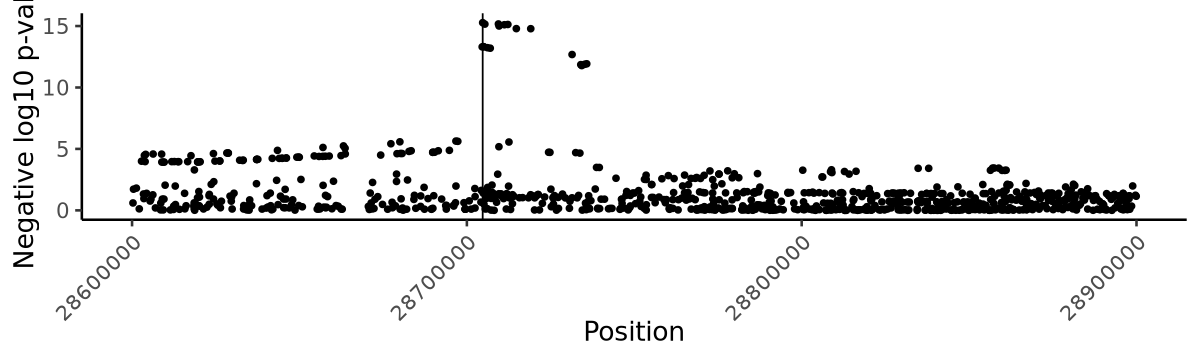

In [89]:
#chr12-52884847-52885147
options(repr.plot.width=10, repr.plot.height=3)
p1 <- ggplot(filter(ALT, chr.hg38 == chr & pos.hg38 > region[1] & pos.hg38 < region[2]), 
      aes(x=pos.hg38, y=-log10(P))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_GWAS_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 2330 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 2330 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

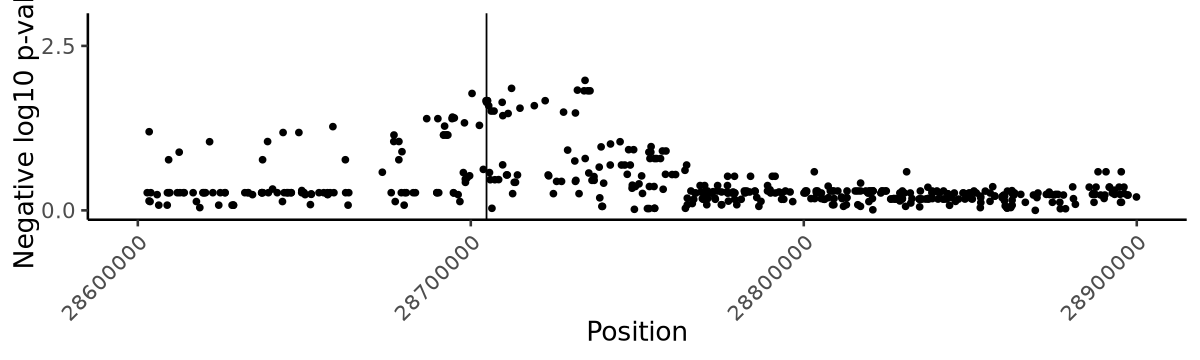

In [90]:
p1 <- ggplot(eqtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))
p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_eQTL_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 2240 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 2240 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

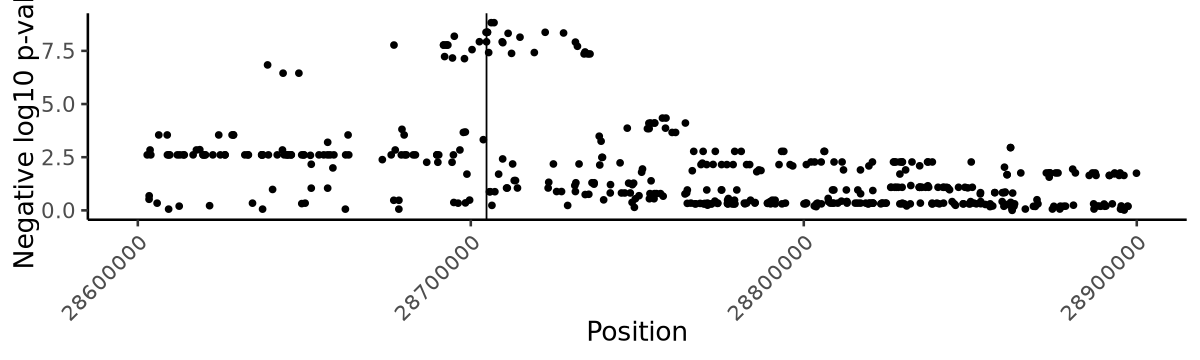

In [91]:
p1 <- ggplot(ATAC.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_caQTL_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

Warning message:
“Removed 2240 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 2240 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2

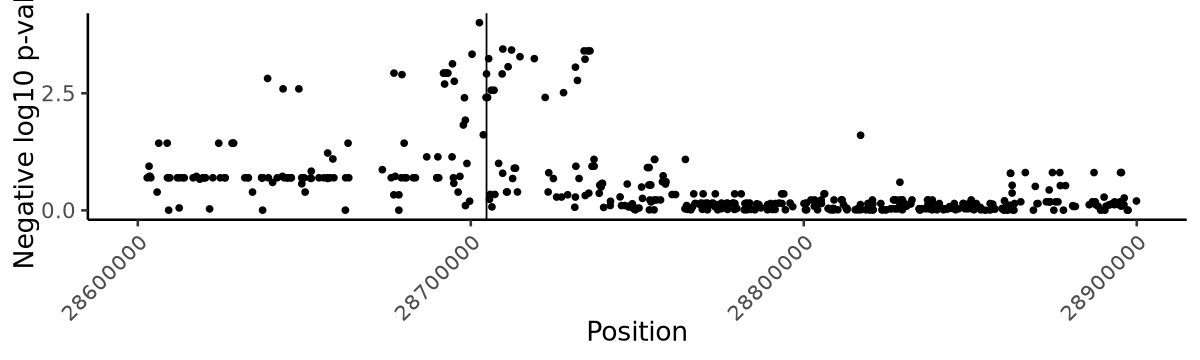

In [92]:
p1 <- ggplot(H3K27ac.qtl.res, aes(x=pos, y=-log10(pval_nominal))) + geom_point() + 
    theme_classic(base_size=16) +
    labs(x="Position",y="Negative log10 p-value") +
    xlim(region) + 
    geom_vline(xintercept = variant.pos) +
    theme(legend.position='none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))  +
    scale_y_continuous(breaks = seq(0, 25, by = 2.5))

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_Locus_Zoom_H3K27acQTL_100kb_v2.pdf'), width=10, height=3)
p1
dev.off()

In [93]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(eQTL.post.mean[str_detect(rownames(eQTL.post.mean), gene),]), 
          sd=unlist(eQTL.post.sd[str_detect(rownames(eQTL.post.sd), gene),]),
          ct=colnames(eQTL.post.mean),
          lfsr=unlist(eQTL.post.lfsr[str_detect(rownames(eQTL.post.lfsr), gene),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_eQTL_',gene,'.pdf'), width=6, height=4)
p1
dev.off()

ERROR: Error in data.frame(mean = unlist(eQTL.post.mean[str_detect(rownames(eQTL.post.mean), : arguments imply differing number of rows: 0, 8


In [ ]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(eQTL.post.mean[str_detect(rownames(eQTL.post.mean), gene),]), 
          sd=unlist(eQTL.post.sd[str_detect(rownames(eQTL.post.sd), gene),]),
          ct=colnames(eQTL.post.mean),
          lfsr=unlist(eQTL.post.lfsr[str_detect(rownames(eQTL.post.lfsr), gene),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_eQTL_',gene,'.pdf'), width=6, height=4)
p1
dev.off()

pdf 
  2

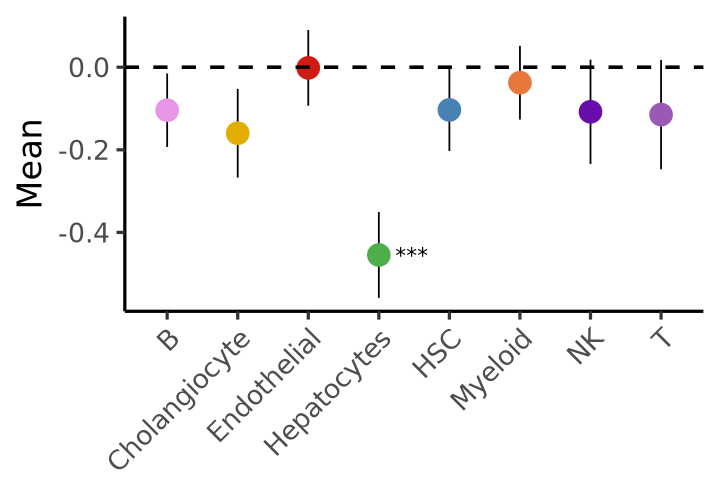

In [97]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(eQTL.post.mean[str_detect(rownames(eQTL.post.mean), 'CHEK2'),]), 
          sd=unlist(eQTL.post.sd[str_detect(rownames(eQTL.post.sd), 'CHEK2'),]),
          ct=colnames(eQTL.post.mean),
          lfsr=unlist(eQTL.post.lfsr[str_detect(rownames(eQTL.post.lfsr), 'CHEK2'),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_eQTL_','CHEK2','.pdf'), width=6, height=4)
p1
dev.off()

In [80]:
gene

[1] "CHEK2"

pdf 
  2

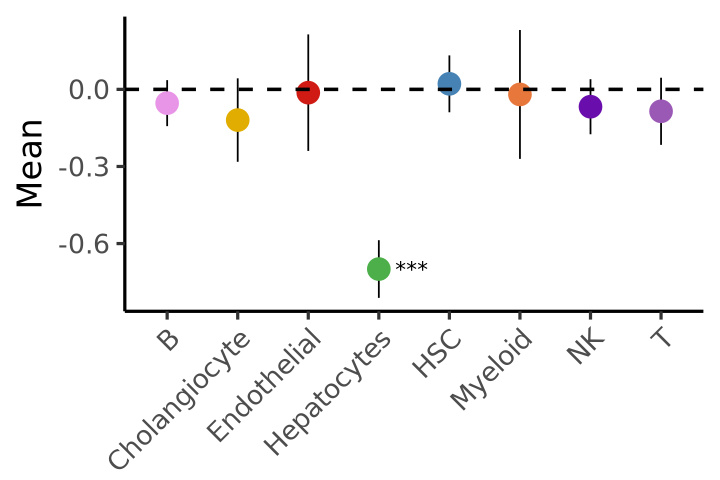

In [77]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(caQTL.post.mean[str_detect(rownames(caQTL.post.mean), atac.feat),]), 
          sd=unlist(caQTL.post.sd[str_detect(rownames(caQTL.post.sd), atac.feat),]),
          ct=colnames(caQTL.post.mean),
          lfsr=unlist(caQTL.post.lfsr[str_detect(rownames(caQTL.post.lfsr), atac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip() 

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_caQTL_',gene,'.pdf'), width=6, height=4)
p1
dev.off()

In [78]:
options(repr.plot.width=6, repr.plot.height=4)

p1 <- data.frame(mean=unlist(H3K27acQTL.post.mean[str_detect(rownames(H3K27acQTL.post.mean), ac.feat),]), 
          sd=unlist(H3K27acQTL.post.sd[str_detect(rownames(H3K27acQTL.post.sd), ac.feat),]),
          ct=colnames(H3K27acQTL.post.mean),
          lfsr=unlist(H3K27acQTL.post.lfsr[str_detect(rownames(H3K27acQTL.post.lfsr), ac.feat),])) %>%
    mutate(low=mean-sd,high=mean+sd, label=ifelse(lfsr < 0.001, '***', ifelse(lfsr < 0.01, '**', ifelse(lfsr < 0.05, '*','')))) %>%
    ggplot(aes(x=mean, y=ct, label=label)) + 
        geom_errorbarh(aes(xmin = low, xmax = high), alpha=1, color='black', height = 0, size=0.5) +
        geom_point(aes(color=ct), size=6) +
        theme_classic(base_size=20) +
        labs(x='Mean', y=NULL) +
        theme(legend.position = 'none', axis.text.x = element_text(angle = 45, vjust = 1, hjust=1)) +
        scale_color_manual(values=celltype_colors) +
        geom_vline(xintercept = 0, linetype = 8, size=1) +
        geom_text(aes(hjust=-0.5, size=200))  + coord_flip()

p1

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_mashr_H3K27acQTL_',gene,'_flipped.pdf'), width=6, height=4)
p1
dev.off()

ERROR: Error in data.frame(mean = unlist(H3K27acQTL.post.mean[str_detect(rownames(H3K27acQTL.post.mean), : arguments imply differing number of rows: 0, 8


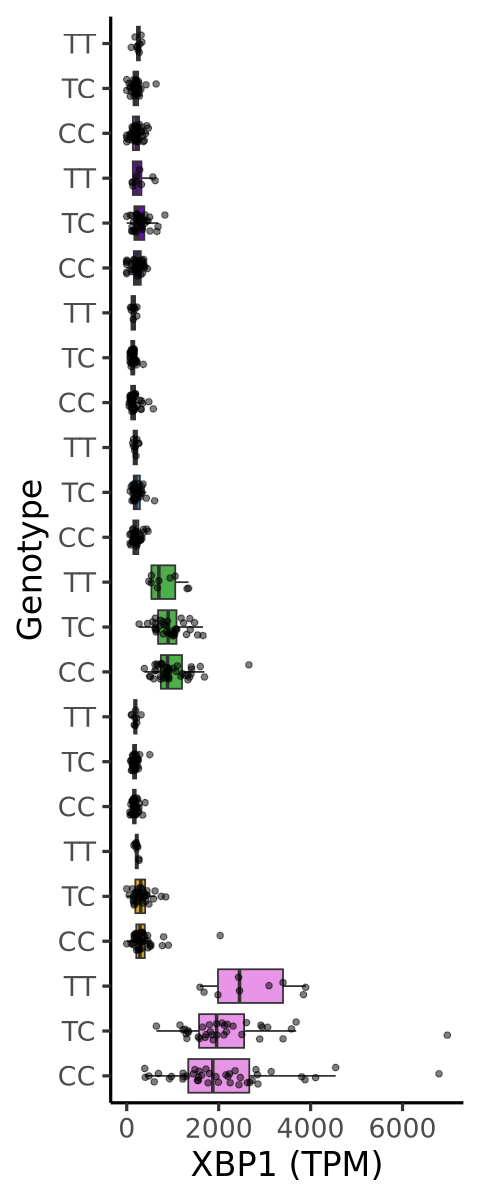

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


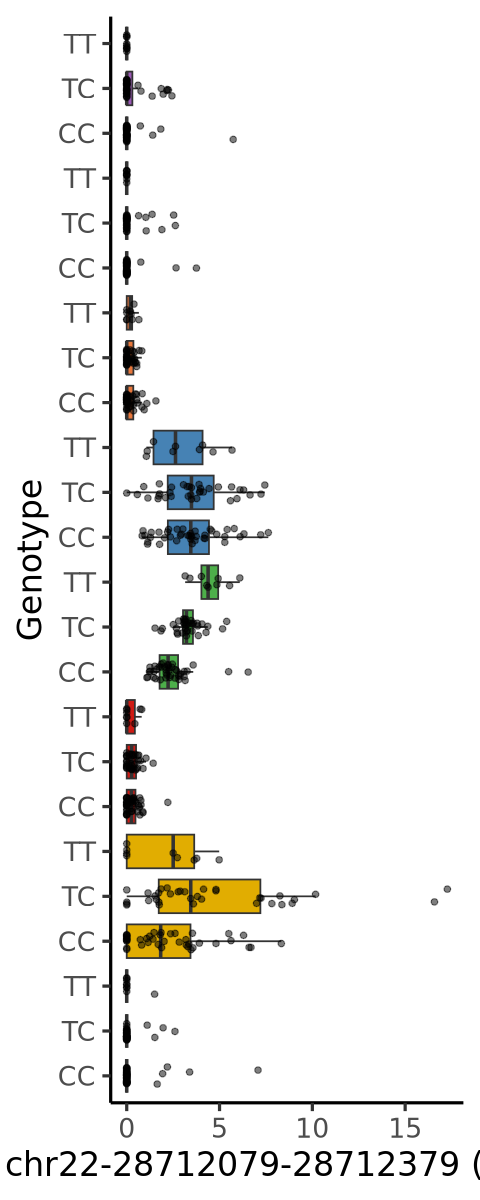

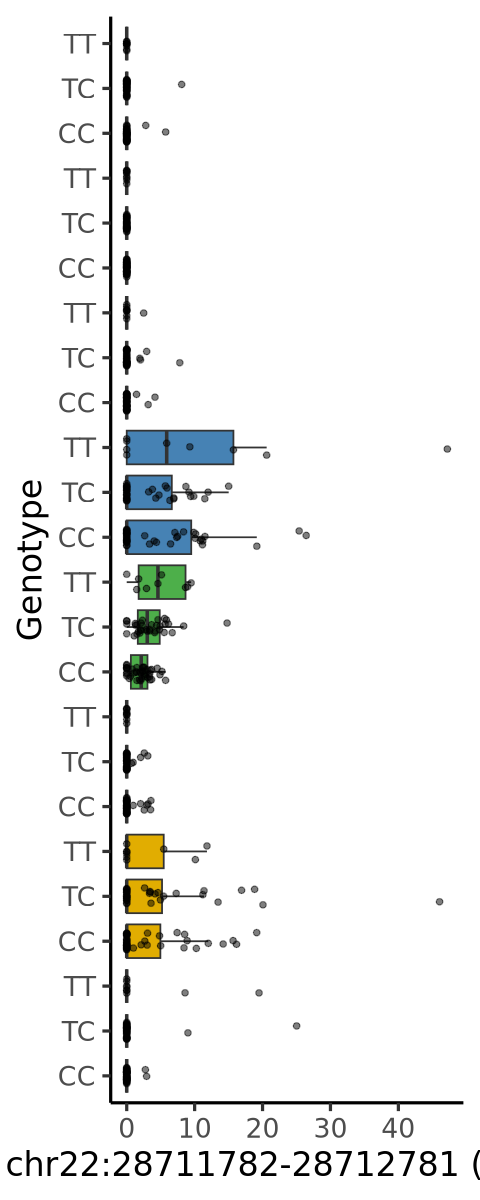

In [94]:
options(repr.plot.width=4, repr.plot.height=10)

#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
#dev.off()
#pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
#dev.off()

In [95]:
options(repr.plot.width=4, repr.plot.height=10)

pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_eQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(gene,variant, vcf.df, TPM, celltype_colors, 'TPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_caQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(atac.feat,variant, vcf.df, CPM.ATAC, celltype_colors, 'CPM')
dev.off()
pdf(paste0('/nfs/lab/welison/Liver/Plots/250304_WE_',gene,'_', variant,'_H3K27acQTL_boxplot_flip.pdf'), width=4, heigh=10)
qtl.boxplot.flip(ac.feat,variant, vcf.df, CPM.H3K27ac, celltype_colors, 'CPM')
dev.off()

pdf 
  2

pdf 
  2

Warning message:
“Removed 5 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range (`geom_point()`).”


pdf 
  2